# Convex costs 0.04: RL vs LSM
Out-of-sample comparison of the best v26 agents against the LSM benchmark across convex cost settings. Runs use the monthly swing contract (22 rights) with HHK dynamics; data loaded directly from the logged evaluation CSVs in `logs/<run>/evaluations/`.

In [1]:
import warnings
warnings.filterwarnings('ignore')
from pathlib import Path
import json, math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def get_repo_root():
    p = Path.cwd()
    return next((p for p in [p] + list(p.parents) if (p / ".git").exists()), None)

REPO_ROOT = get_repo_root()
LOGS_DIR, RUNS_DIR, FIG_DIR = REPO_ROOT / "logs", REPO_ROOT / "runs", REPO_ROOT / "figs/convex_costs_0p04"
FIG_DIR.mkdir(parents=True, exist_ok=True)

pd.set_option('display.float_format', lambda x: f'{x:,.6f}')
sns.set_theme(style="whitegrid", context="talk")


In [2]:
RUN_SPECS = [
    {"label": "c0_g1_seed13_s27648", "c": 0.0, "gamma": 1.0, "seed": 13, "step": 27648, "run_name": "SwingOption_20_c0.00_gamma1_13"},
    {"label": "c0.04_g1_seed11_s31744", "c": 0.04, "gamma": 1.0, "seed": 11, "step": 31744, "run_name": "SwingOption_20_c0.04_gamma1_11"},
    {"label": "c0.04_g1.5_seed12_s10240", "c": 0.04, "gamma": 1.5, "seed": 12, "step": 10240, "run_name": "SwingOption_20_c0.04_gamma1.5_12"},
    {"label": "c0.04_g2_seed13_s29696", "c": 0.04, "gamma": 2.0, "seed": 13, "step": 29696, "run_name": "SwingOption_20_c0.04_gamma2_13"},
]

def attach_paths(spec):
    eval_dir = LOGS_DIR / spec["run_name"] / "evaluations"
    return {
        **spec,
        "rl_path": eval_dir / f"rl_episode_{spec['step']}.parquet",
        "lsm_path": eval_dir / "lsm.parquet",
        "config_path": RUNS_DIR / f"{spec['run_name']}.json"
    }

RUN_SPECS = [attach_paths(s) for s in RUN_SPECS]
pd.DataFrame(RUN_SPECS)[["label", "c", "gamma", "seed", "step", "run_name"]]


,label,c,gamma,seed,step,run_name
0,c0_g1_seed13_s27648,0.000000,1.000000,13,27648,SwingOption_20_c0.00_gamma1_13
1,c0.04_g1_seed11_s31744,0.040000,1.000000,11,31744,SwingOption_20_c0.04_gamma1_11
2,c0.04_g1.5_seed12_s10240,0.040000,1.500000,12,10240,SwingOption_20_c0.04_gamma1.5_12
3,c0.04_g2_seed13_s29696,0.040000,2.000000,13,29696,SwingOption_20_c0.04_gamma2_13


In [3]:
def process_eval(df, cfg, method):
    df = df.copy()
    dt = cfg["maturity"] / cfg["n_rights"]
    df["discount"] = np.exp(-cfg["risk_free_rate"] * (df["time_step"] + 1) * dt)
    
    if method == "RL":
        df["net_step"] = df["reward"]
        df["cost_step"] = df["exercise_cost"] * df["discount"]
    else:
        df["net_step"] = df["payoff"] * df["discount"]
        df["cost_step"] = df["exercise_cost"] * df["discount"]
        
    df["gross_step"] = df["payoff_gross"] * df["discount"] if "payoff_gross" in df else df["net_step"] + df["cost_step"]
    
    res = df.groupby("path").agg(
        net_pv=("net_step", "sum"), 
        gross_pv=("gross_step", "sum"),
        cost=("cost_step", "sum"), 
        qty=("q_t", "sum"), 
        max_step=("time_step", "max")
    ).reset_index()
    
    first_ex_df = df[df["q_t"] > 1e-8].groupby("path")["time_step"].min().reset_index(name="first_ex")
    res = res.merge(first_ex_df, on="path", how="left")
    res["method"] = method
    return res

def save_fig(fig, name):
    for ext in ("png", "pdf"): 
        fig.savefig(FIG_DIR / f"{name}.{ext}", bbox_inches="tight", dpi=300)
    # plt.close(fig)

def calc_stats(g):
    st = {"paths": len(g)}
    for k in ["net_pv", "cost", "gross_pv", "qty"]:
        st[f"{k}_mean"] = g[k].mean()
        st[f"{k}_se"] = g[k].std(ddof=1) / math.sqrt(len(g))
    return pd.Series(st)


In [4]:
def load_and_prepare(spec):
    with open(spec["config_path"]) as f: cfg = json.load(f)

    rl_df, lsm_df = pd.read_parquet(spec["rl_path"]), pd.read_parquet(spec["lsm_path"])
    rl_paths, lsm_paths = process_eval(rl_df, cfg, "RL"), process_eval(lsm_df, cfg, "LSM")

    merged = rl_paths.merge(lsm_paths, on="path", suffixes=("_rl", "_lsm"))
    for k, col in [("pv", "net_pv"), ("cost", "cost"), ("gross", "gross_pv"), ("qty", "qty")]:
        merged[f"delta_{k}"] = merged[f"{col}_rl"] - merged[f"{col}_lsm"]

    profiles = []
    for m, d in [("RL", rl_df), ("LSM", lsm_df)]:
        idx = pd.MultiIndex.from_product([d["path"].unique(), range(cfg["n_rights"])], names=["path", "time_step"])
        prof = d.set_index(["path", "time_step"])["q_t"].reindex(idx, fill_value=0).groupby("time_step").mean().reset_index(name="q_mean")
        prof["method"] = m
        profiles.append(prof)

    meta = {k: spec[k] for k in ["label", "c", "gamma", "seed", "step", "run_name"]}
    paths = pd.concat([rl_paths, lsm_paths], ignore_index=True)

    for df in [paths, merged] + profiles:
        for k, v in meta.items(): df[k] = v

    return {
        "spec": spec, "cfg": cfg, "rl_df": rl_df, "lsm_df": lsm_df,
        "paths": paths, "merged": merged, "profile": pd.concat(profiles, ignore_index=True),
    }

data = [load_and_prepare(s) for s in RUN_SPECS]
paths_all = pd.concat([d["paths"] for d in data], ignore_index=True)
merged_all = pd.concat([d["merged"] for d in data], ignore_index=True)
prof_all = pd.concat([d["profile"] for d in data], ignore_index=True)

paths_all.groupby("label")["path"].nunique().to_frame(name="rows")


,rows
label,
c0.04_g1.5_seed12_s10240,65536
c0.04_g1_seed11_s31744,65536
c0.04_g2_seed13_s29696,65536
c0_g1_seed13_s27648,65536


In [5]:
order = [s["label"] for s in RUN_SPECS]
label_map = {s["label"]: f"c={s['c']}, g={s['gamma']}" for s in RUN_SPECS}

In [22]:
summary_methods = paths_all.groupby(["label", "c", "gamma", "seed", "step", "method"]).apply(calc_stats, include_groups=False).reset_index()
lsm_lookup = summary_methods.query("method == 'LSM'").set_index("label")["net_pv_mean"].to_dict()

delta_summary = merged_all.groupby(["label", "c", "gamma", "seed", "step"]).agg(
    paths=("path", "count"),
    delta_pv_mean=("delta_pv", "mean"), delta_pv_se=("delta_pv", lambda x: x.std(ddof=1) / math.sqrt(len(x))),
    delta_cost_mean=("delta_cost", "mean"), delta_gross_mean=("delta_gross", "mean"), delta_qty_mean=("delta_qty", "mean")
).reset_index()

delta_summary["delta_pct_vs_lsm"] = delta_summary["delta_pv_mean"] / delta_summary["label"].map(lsm_lookup)
delta_summary["delta_pct_se"] = delta_summary["delta_pv_se"] / delta_summary["label"].map(lsm_lookup)

summary_methods.sort_values(["c", "gamma", "method"])[["label", "method", "net_pv_mean", "net_pv_se", "cost_mean", "qty_mean"]]

,label,method,net_pv_mean,net_pv_se,cost_mean,qty_mean
6,c0_g1_seed13_s27648,LSM,2.660224,0.010854,0.000000,11.382233
7,c0_g1_seed13_s27648,RL,2.655422,0.010861,0.000000,11.500898
2,c0.04_g1_seed11_s31744,LSM,2.223323,0.010133,0.400514,10.039276
3,c0.04_g1_seed11_s31744,RL,2.218973,0.010241,0.395896,9.923547
0,c0.04_g1.5_seed12_s10240,LSM,2.071244,0.009919,0.536440,9.508209
1,c0.04_g1.5_seed12_s10240,RL,2.095703,0.009950,0.503461,9.723230
4,c0.04_g2_seed13_s29696,LSM,1.862010,0.009554,0.693434,8.691162
5,c0.04_g2_seed13_s29696,RL,1.973531,0.009755,0.525595,9.478016


In [23]:
summary_methods

,label,c,gamma,seed,step,method,paths,net_pv_mean,net_pv_se,cost_mean,cost_se,gross_pv_mean,gross_pv_se,qty_mean,qty_se
0,c0.04_g1.5_seed12_s10240,0.040000,1.500000,12,10240,LSM,"65,536.000000",2.071244,0.009919,0.536440,0.001747,2.607685,0.011365,9.508209,0.030965
1,c0.04_g1.5_seed12_s10240,0.040000,1.500000,12,10240,RL,"65,536.000000",2.095703,0.009950,0.503461,0.001619,2.599164,0.011313,9.723230,0.030472
2,c0.04_g1_seed11_s31744,0.040000,1.000000,11,31744,LSM,"65,536.000000",2.223323,0.010133,0.400514,0.001234,2.623837,0.011146,10.039276,0.030925
3,c0.04_g1_seed11_s31744,0.040000,1.000000,11,31744,RL,"65,536.000000",2.218973,0.010241,0.395896,0.001207,2.614869,0.011232,9.923547,0.030243
4,c0.04_g2_seed13_s29696,0.040000,2.000000,13,29696,LSM,"65,536.000000",1.862010,0.009554,0.693434,0.002452,2.555444,0.011619,8.691162,0.030736
5,c0.04_g2_seed13_s29696,0.040000,2.000000,13,29696,RL,"65,536.000000",1.973531,0.009755,0.525595,0.001763,2.499127,0.011211,9.478016,0.029195
6,c0_g1_seed13_s27648,0.000000,1.000000,13,27648,LSM,"65,536.000000",2.660224,0.010854,0.000000,0.000000,2.660224,0.010854,11.382233,0.030661
7,c0_g1_seed13_s27648,0.000000,1.000000,13,27648,RL,"65,536.000000",2.655422,0.010861,0.000000,0.000000,2.655422,0.010861,11.500898,0.030549


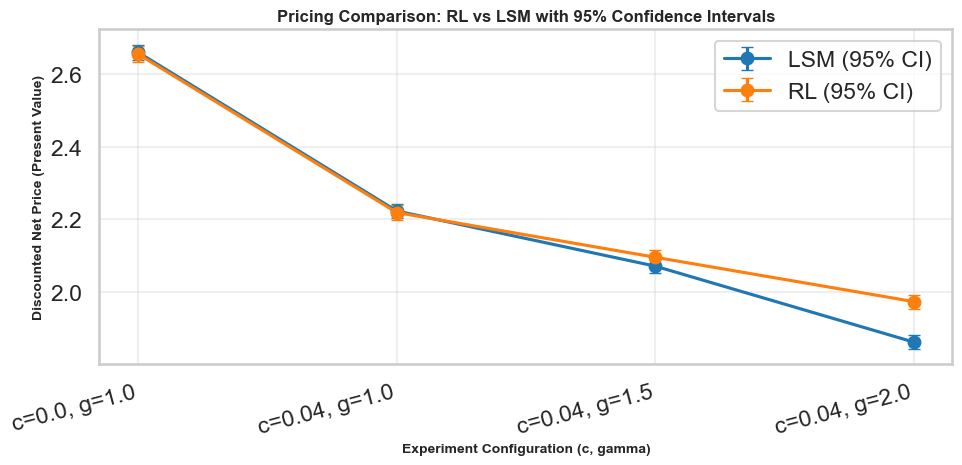

In [24]:
order = [s["label"] for s in RUN_SPECS]
label_map = {s["label"]: f"c={s['c']}, g={s['gamma']}" for s in RUN_SPECS}

fig, ax = plt.subplots(figsize=(10, 5))
for m, c in zip(["LSM", "RL"], ["tab:blue", "tab:orange"]):
    sub = summary_methods.query("method == @m").set_index("label").loc[order].reset_index()
    ax.errorbar(range(len(order)), sub["net_pv_mean"], yerr=1.96*sub["net_pv_se"], fmt="o-", color=c, label=f"{m} (95% CI)", capsize=4)

ax.set_xticks(range(len(order)))
ax.set_xticklabels([label_map[o] for o in order], rotation=15, ha='right')
ax.set_ylabel("Discounted Net Price (Present Value)", fontsize=10, fontweight='bold')
ax.set_xlabel("Experiment Configuration (c, gamma)", fontsize=10, fontweight='bold')
ax.set_title("Pricing Comparison: RL vs LSM with 95% Confidence Intervals", fontsize=12, fontweight='bold')
ax.legend(); ax.grid(alpha=0.3); plt.tight_layout(); plt.show()



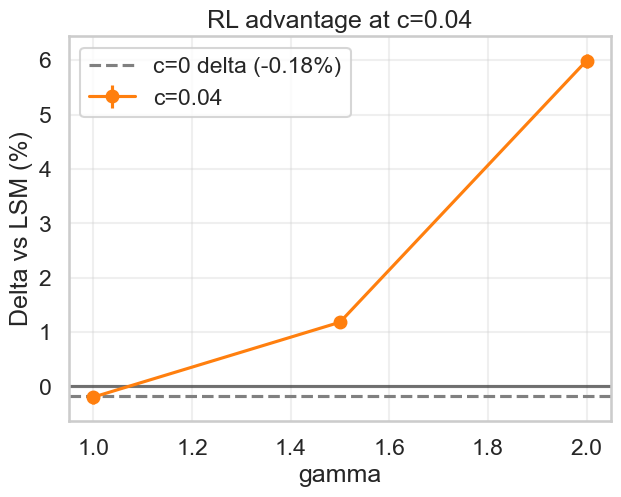

In [25]:
fig, ax = plt.subplots(figsize=(7, 5))
c005 = delta_summary.query("c == 0.04").sort_values("gamma") 
ax.errorbar(c005["gamma"], c005["delta_pct_vs_lsm"]*100, yerr=1.96*c005["delta_pct_se"]*100, fmt="o-", color="tab:orange", label="c=0.04")

base = delta_summary.query("c == 0.0")
if not base.empty:
    b_val = float(base["delta_pct_vs_lsm"].iloc[0])*100
    ax.axhline(b_val, color="gray", linestyle="--", label=f"c=0 delta ({b_val:.2f}%)")

ax.axhline(0, color="k", alpha=0.6)
ax.set(xlabel="gamma", ylabel="Delta vs LSM (%)", title="RL advantage at c=0.04"); ax.legend(); ax.grid(alpha=0.3); plt.show()


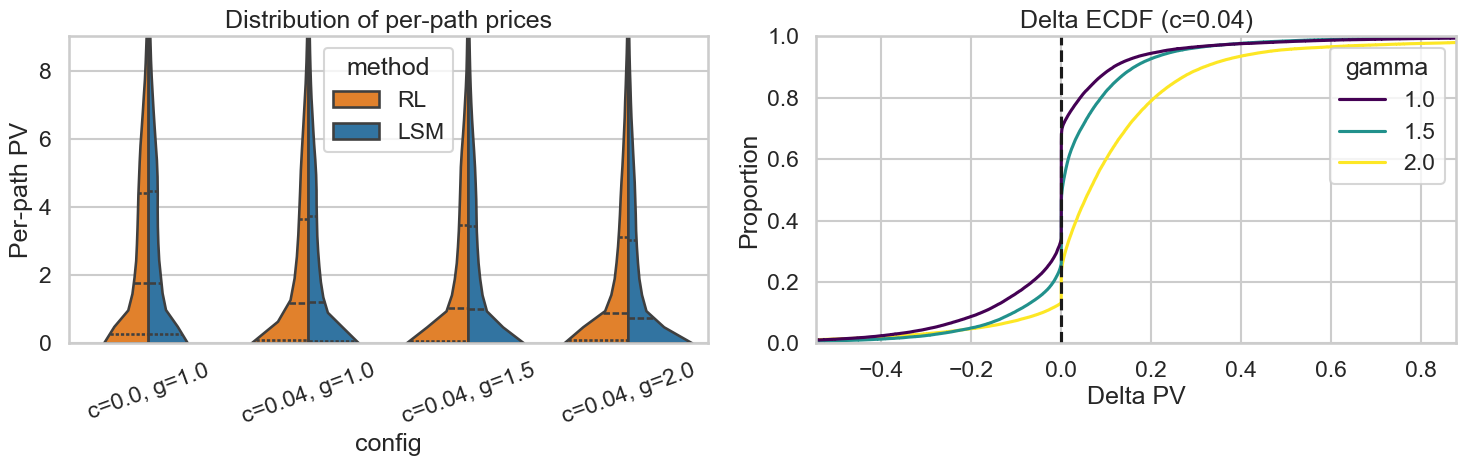

In [26]:
paths_all["config"] = paths_all.apply(lambda r: f"c={r['c']}, g={r['gamma']}", axis=1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
sns.violinplot(data=paths_all, x="config", y="net_pv", hue="method", order=[label_map[o] for o in order], palette={"RL": "tab:orange", "LSM": "tab:blue"}, split=True, inner="quartile", cut=0, ax=ax1)
ax1.set(ylim=np.percentile(paths_all["net_pv"], [0, 98]), ylabel="Per-path PV", title="Distribution of per-path prices")
ax1.tick_params(axis="x", rotation=20)

sns.ecdfplot(data=merged_all.query("c == 0.04"), x="delta_pv", hue="gamma", palette="viridis", ax=ax2)
ax2.axvline(0, color="k", ls="--")
ax2.set(xlim=np.percentile(merged_all.query("c == 0.04")["delta_pv"], [1, 99]), xlabel="Delta PV", title="Delta ECDF (c=0.04)")
plt.tight_layout(); plt.show()


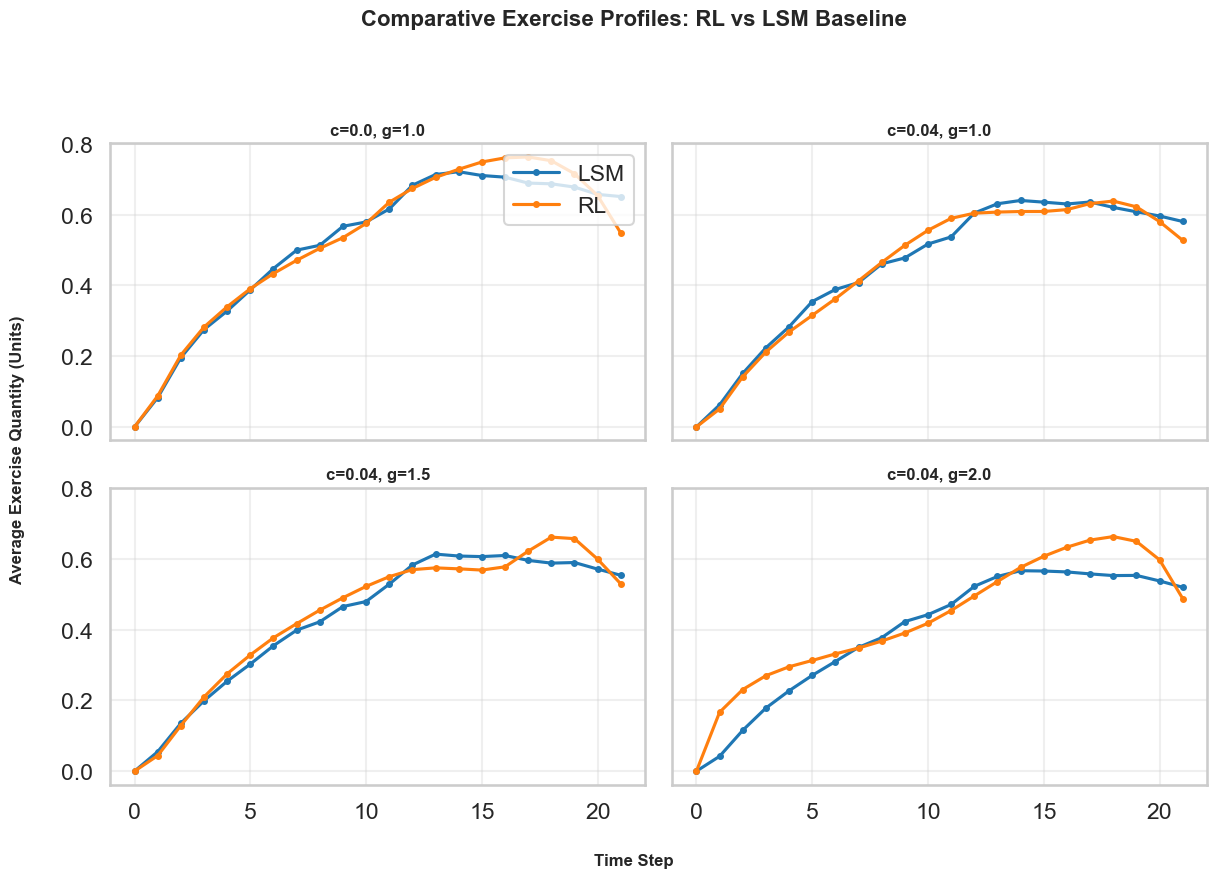

In [27]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=True, sharey=True)
for ax, lbl in zip(axes.ravel(), order):
    for m, c in [("LSM", "tab:blue"), ("RL", "tab:orange")]:
        p = prof_all.query("label == @lbl and method == @m")
        ax.plot(p["time_step"], p["q_mean"], "o-", label=m, color=c, markersize=4)
    ax.set_title(label_map[lbl], fontsize=12, fontweight='bold')
    ax.grid(alpha=0.3)

# Add shared axis labels for a cleaner quant look
fig.text(0.5, -0.02, 'Time Step', ha='center', fontsize=12, fontweight='bold')
fig.text(-0.02, 0.5, 'Average Exercise Quantity (Units)', va='center', rotation='vertical', fontsize=12, fontweight='bold')
fig.suptitle('Comparative Exercise Profiles: RL vs LSM Baseline', fontsize=16, fontweight='bold', y=1.05)

axes[0,0].legend(loc='upper right')
plt.tight_layout()
plt.show()


## Cost decomposition and distributions across configs

In [6]:
path_stats = paths_all.rename(columns={"net_pv": "PV_net", "gross_pv": "PV_gross", "cost": "PV_cost", "qty": "Q_total"}).copy()
path_stats["config"] = path_stats.get("config", path_stats["label"])
path_stats["cost_per_unit"] = np.where(path_stats["Q_total"] > 0, path_stats["PV_cost"] / path_stats["Q_total"], np.nan)
path_stats["cost_per_unit_clipped"] = path_stats["cost_per_unit"].clip(*np.nanpercentile(path_stats["cost_per_unit"].dropna(), [1, 99]))

summary_df = path_stats.groupby(["config", "label", "method"], as_index=False).agg(
    PV_gross_mean=("PV_gross", "mean"),
    PV_cost_mean=("PV_cost", "mean"),
    PV_net_mean=("PV_net", "mean"),
    cost_per_unit_mean=("cost_per_unit", "mean"),
    paths=("path", "count")
)
summary_df

,config,label,method,PV_gross_mean,PV_cost_mean,PV_net_mean,cost_per_unit_mean,paths
0,c0.04_g1.5_seed12_s10240,c0.04_g1.5_seed12_s10240,LSM,2.607685,0.536440,2.071244,0.056418,65536
1,c0.04_g1.5_seed12_s10240,c0.04_g1.5_seed12_s10240,RL,2.599164,0.503461,2.095703,0.044044,65536
2,c0.04_g1_seed11_s31744,c0.04_g1_seed11_s31744,LSM,2.623837,0.400514,2.223323,0.039894,65536
3,c0.04_g1_seed11_s31744,c0.04_g1_seed11_s31744,RL,2.614869,0.395896,2.218973,0.039902,65536
4,c0.04_g2_seed13_s29696,c0.04_g2_seed13_s29696,LSM,2.555444,0.693434,1.862010,0.079786,65536
5,c0.04_g2_seed13_s29696,c0.04_g2_seed13_s29696,RL,2.499127,0.525595,1.973531,0.046160,65536
6,c0_g1_seed13_s27648,c0_g1_seed13_s27648,LSM,2.660224,0.000000,2.660224,0.000000,65536
7,c0_g1_seed13_s27648,c0_g1_seed13_s27648,RL,2.655422,0.000000,2.655422,0.000000,65536


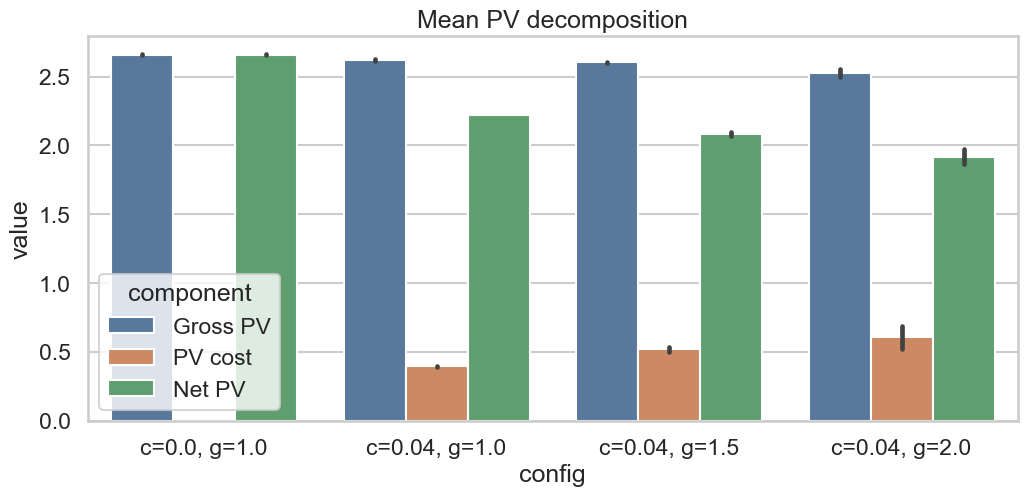

In [29]:
decomp = summary_df.melt(["config", "label", "method", "paths"], ["PV_gross_mean", "PV_cost_mean", "PV_net_mean"], "component")
decomp["component"] = decomp["component"].map({"PV_gross_mean": "Gross PV", "PV_cost_mean": "PV cost", "PV_net_mean": "Net PV"})

fig, ax = plt.subplots(figsize=(12, 5))
sns.barplot(data=decomp, x="config", y="value", hue="component", palette={"Gross PV": "#4e79a7", "PV cost": "#dd8452", "Net PV": "#55a868"}, ax=ax)
ax.set(title="Mean PV decomposition"); plt.show()


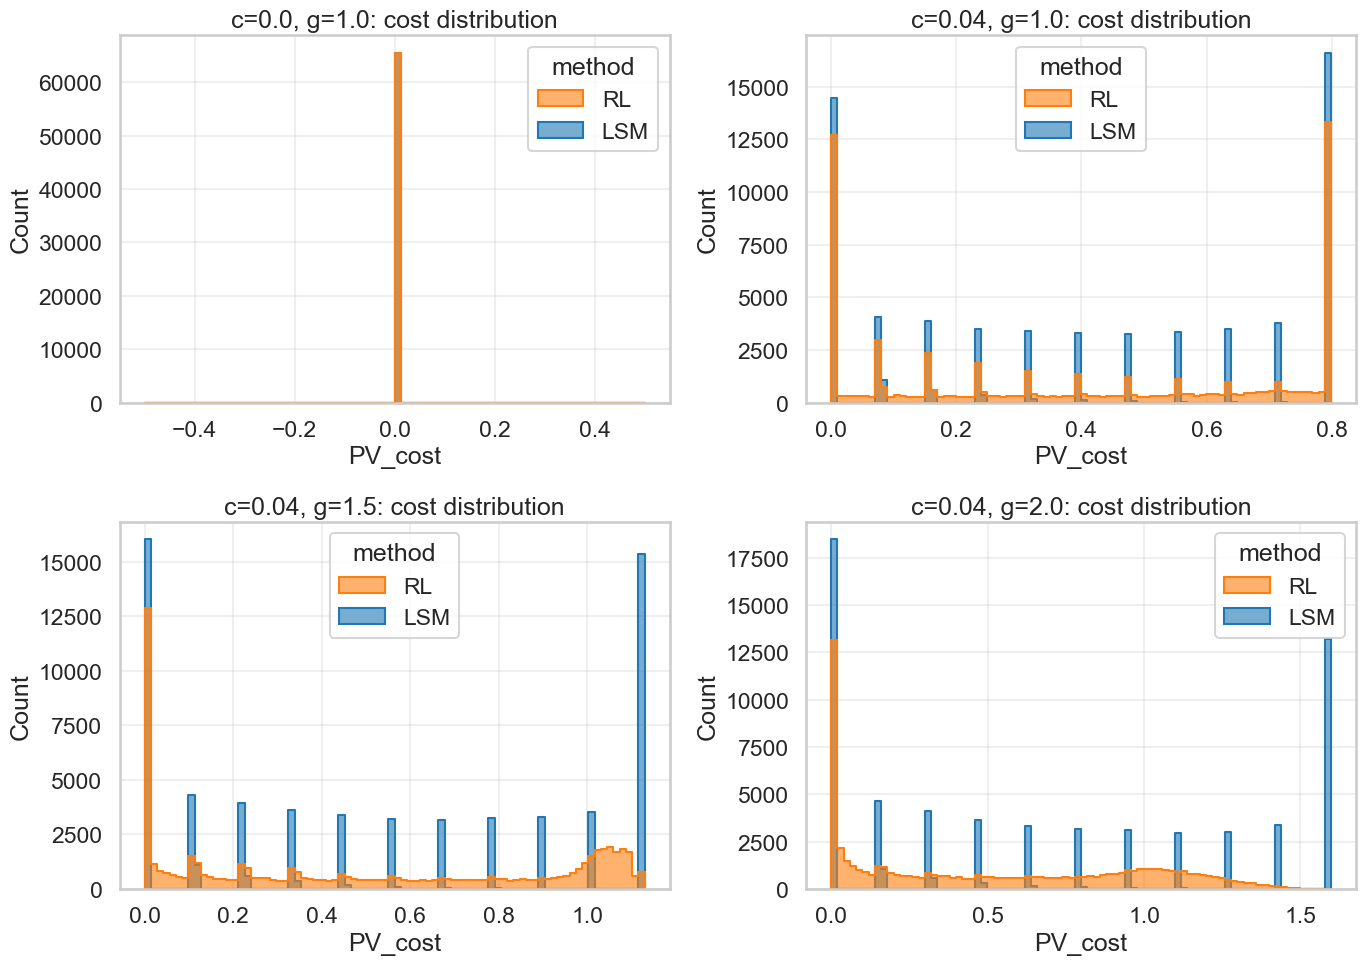

In [30]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for ax, lbl in zip(axes.ravel(), order):
    sns.histplot(data=path_stats.query("label == @lbl"), x="PV_cost", hue="method", bins=80, palette={"RL": "tab:orange", "LSM": "tab:blue"}, element="step", ax=ax, alpha=0.6)
    ax.set(title=f"{label_map[lbl]}: cost distribution"); ax.grid(alpha=0.3)
fig.tight_layout(); plt.show()


## Cost diagnostics across configs

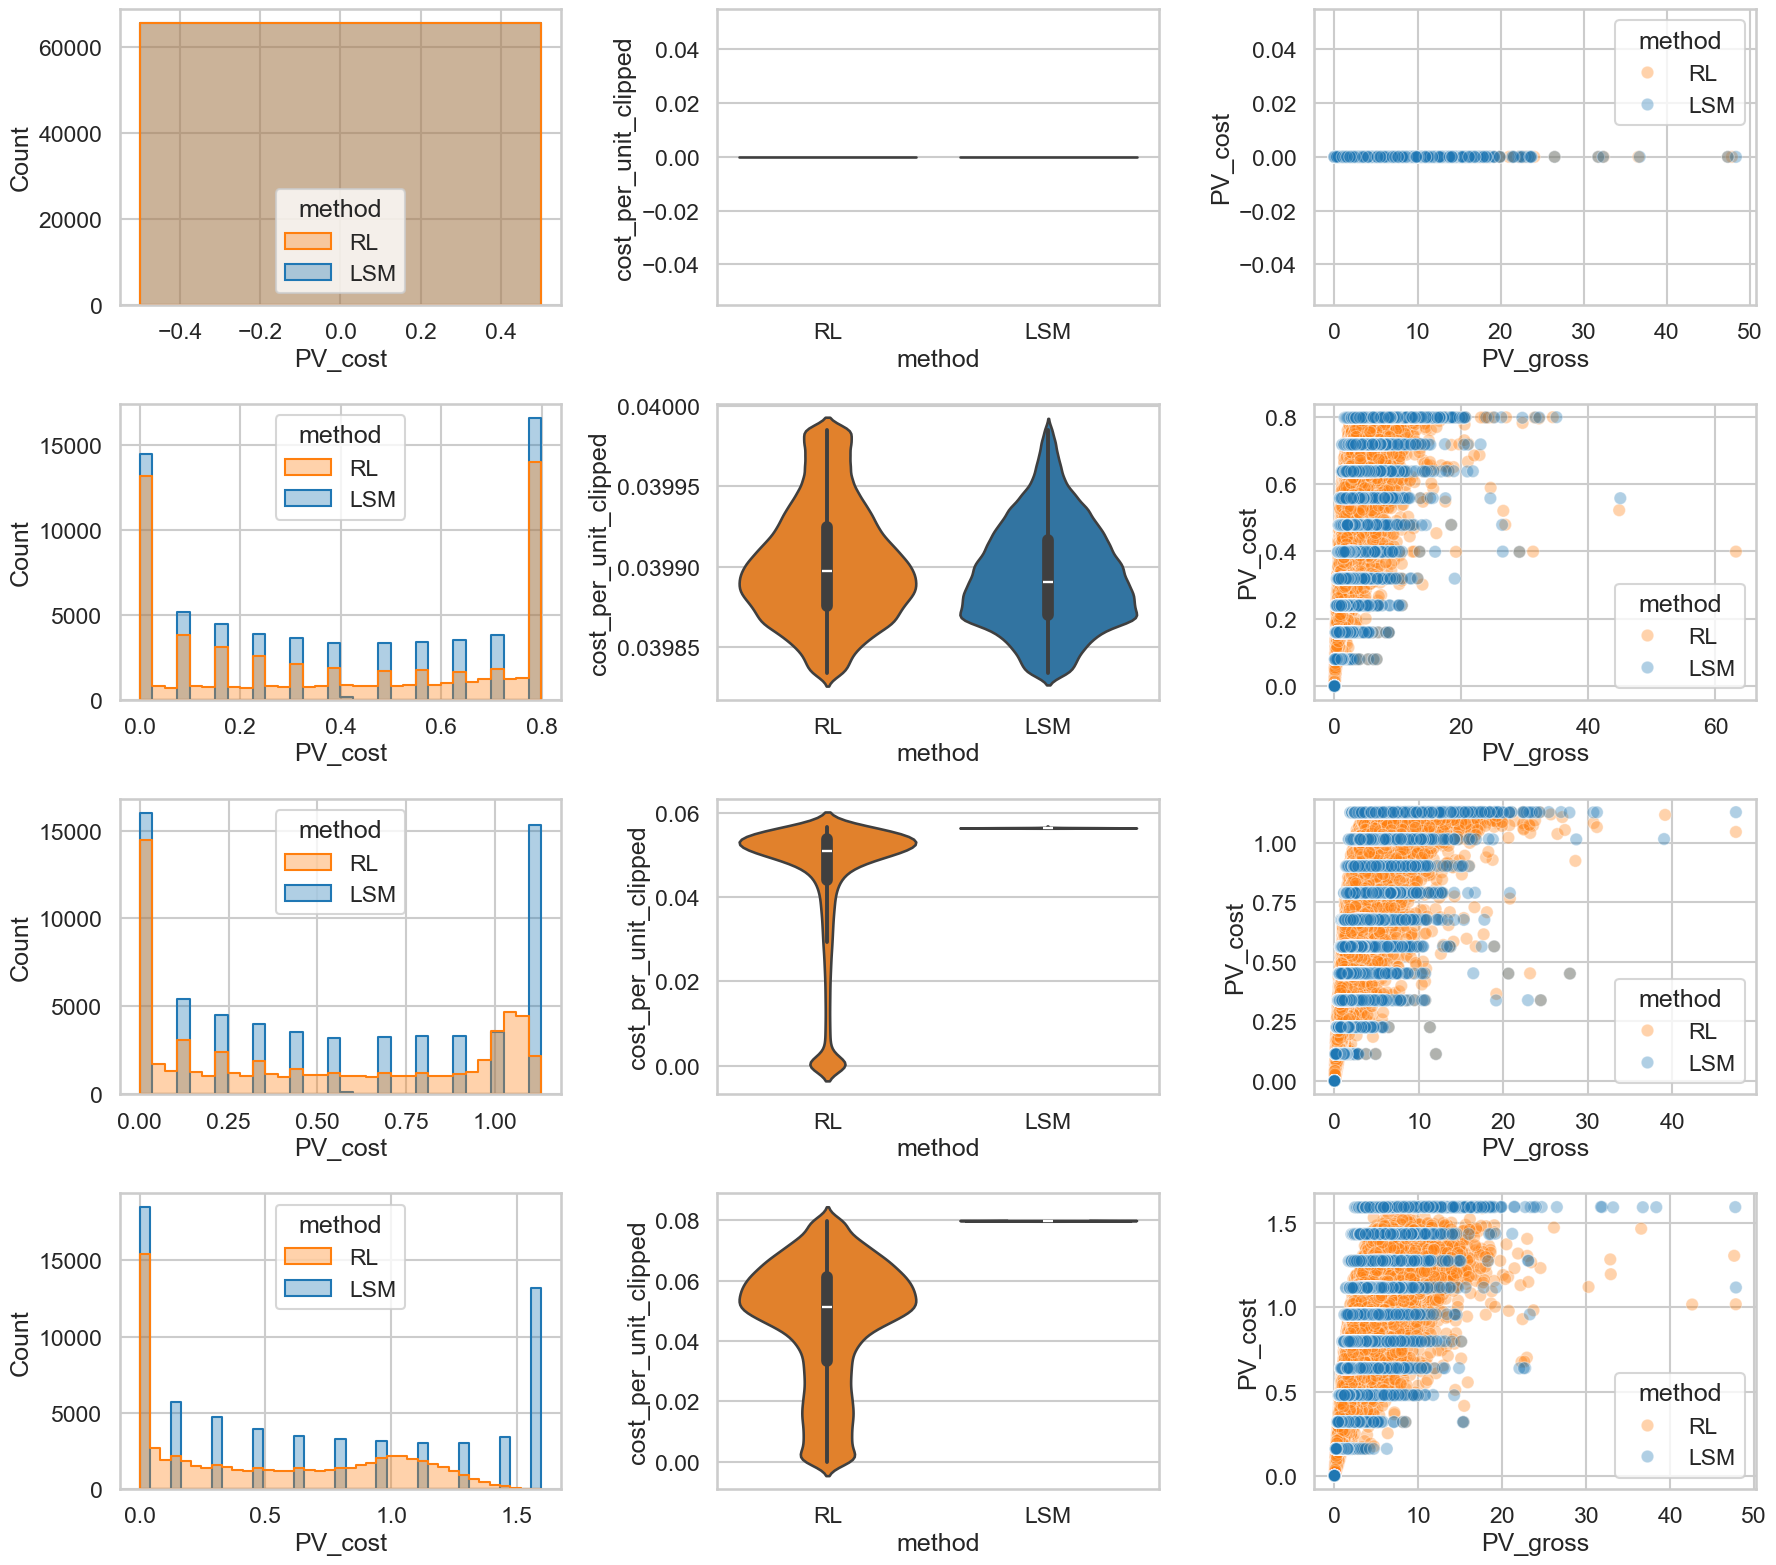

In [31]:
fig, axes = plt.subplots(len(order), 3, figsize=(18, 4*len(order)))
for r, lbl in enumerate(order):
    sub = path_stats.query("label == @lbl")
    sns.histplot(data=sub, x="PV_cost", hue="method", alpha=0.35, element="step", ax=axes[r,0], palette={"RL": "tab:orange", "LSM": "tab:blue"})
    sns.violinplot(data=sub, x="method", y="cost_per_unit_clipped", hue="method", palette={"RL": "tab:orange", "LSM": "tab:blue"}, ax=axes[r,1], legend=False)
    sns.scatterplot(data=sub, x="PV_gross", y="PV_cost", hue="method", alpha=0.35, ax=axes[r,2], palette={"RL": "tab:orange", "LSM": "tab:blue"})
plt.tight_layout(); plt.show()


## Cost–reward scatter diagnostics (per config)
Adaptation of the plotly diagnostics: four small-multiple figures (one per config) with per-path reward vs cost and spot-conditioned scatter views.


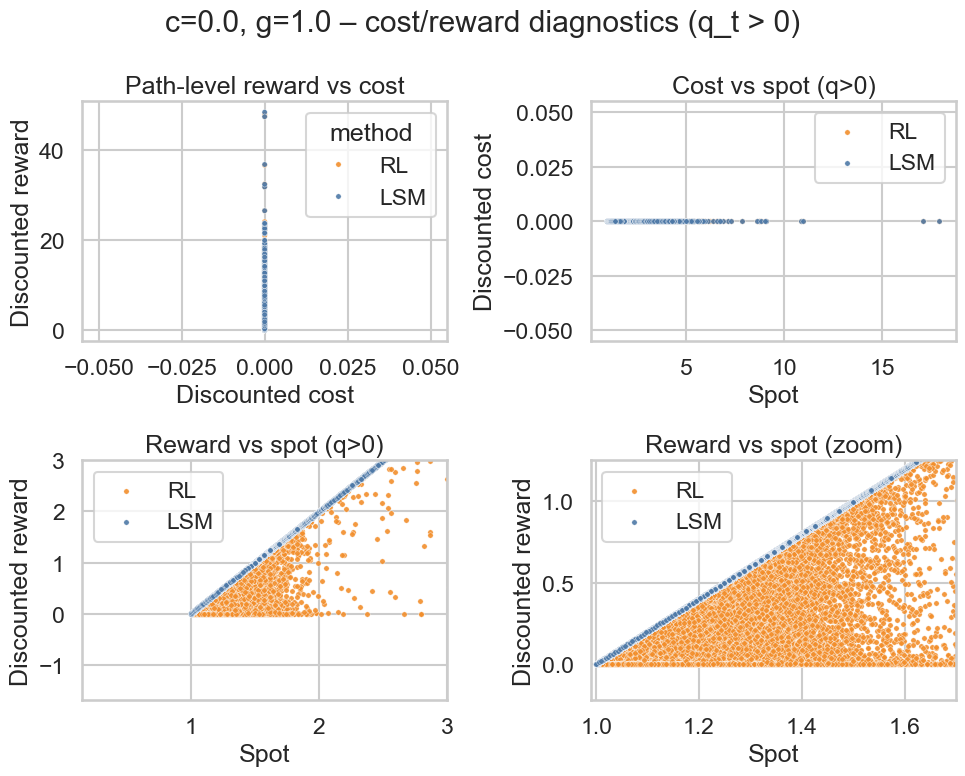

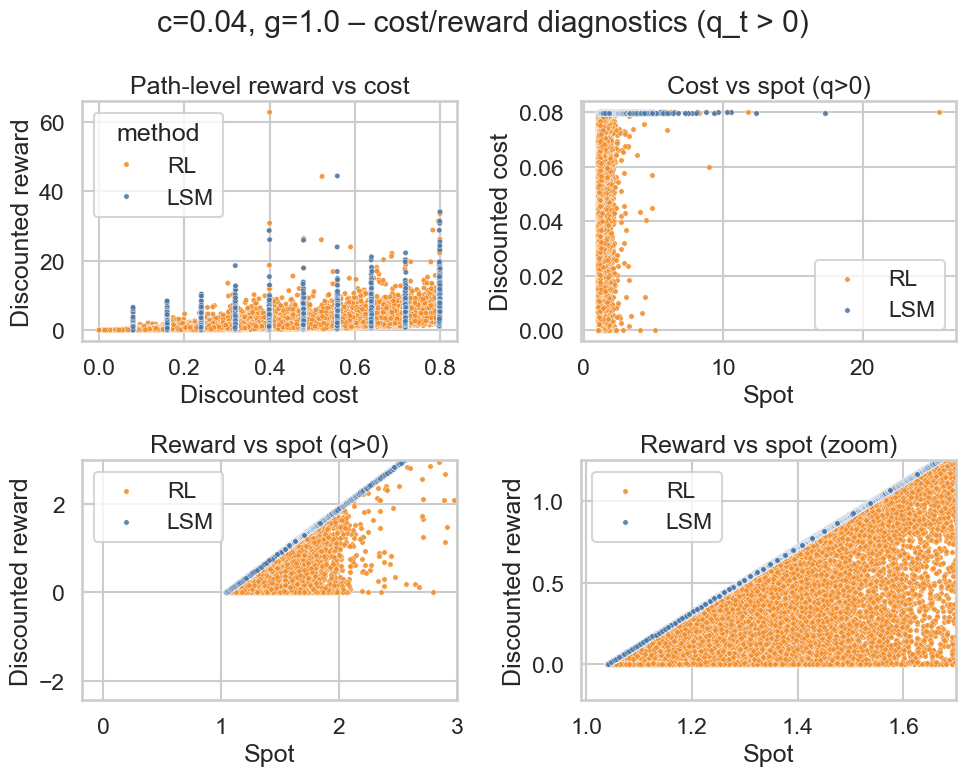

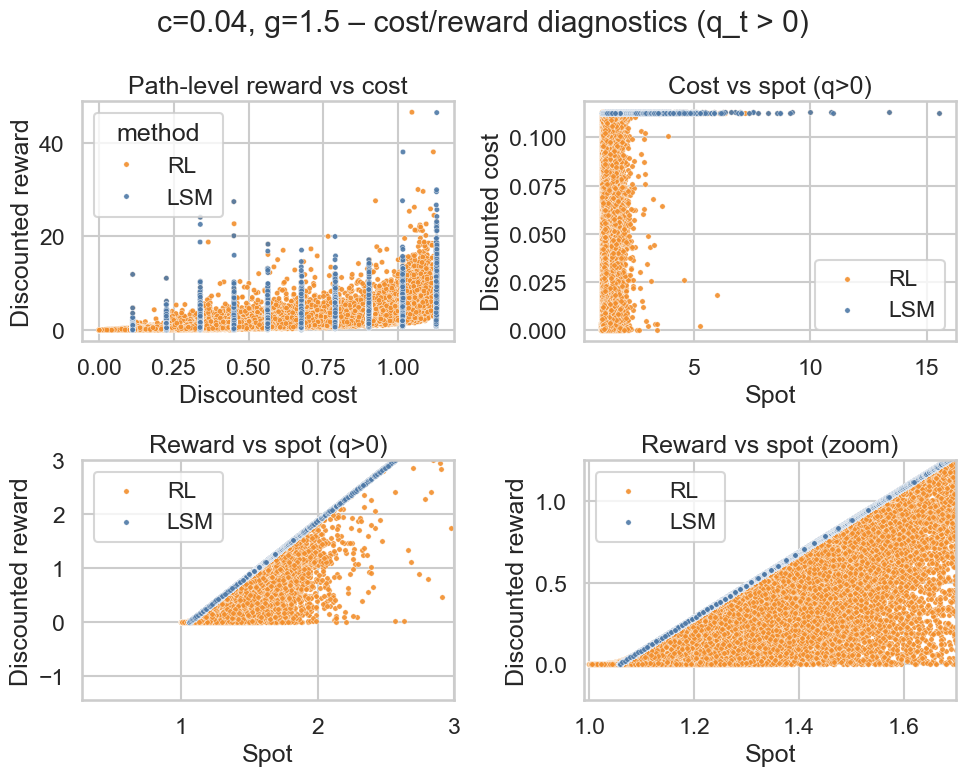

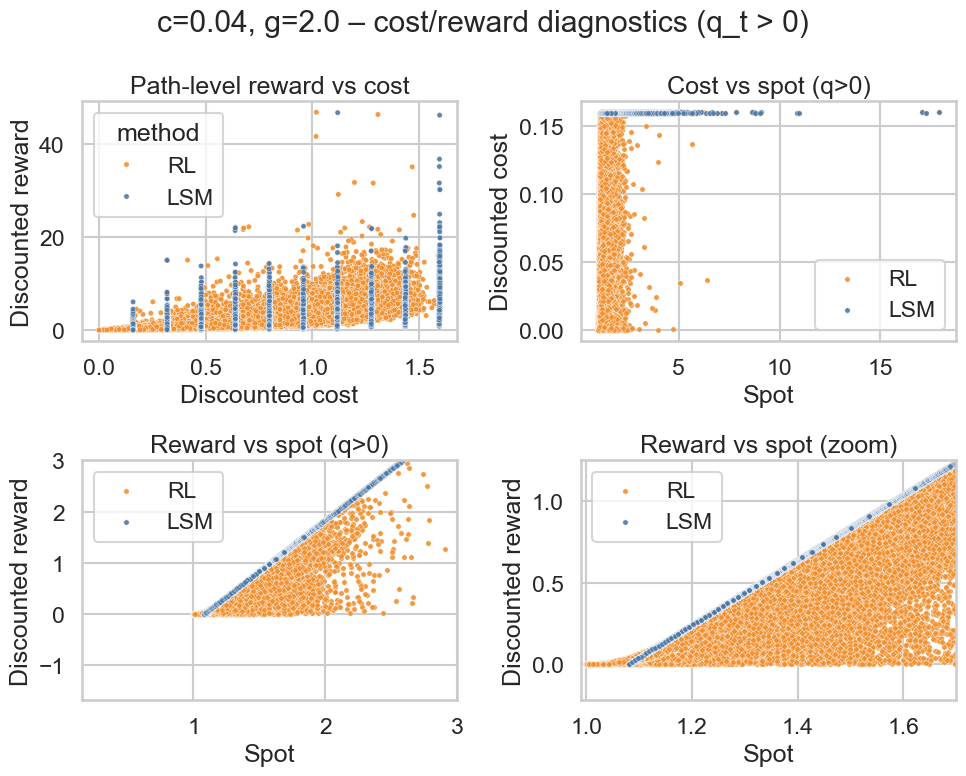

In [32]:
palette_diag = {"RL": "#f28e2b", "LSM": "#4e79a7"}

for d in data:
    lbl, cfg, spec = d["spec"]["label"], d["cfg"], d["spec"]
    cfg_name = label_map[lbl]
    dt = cfg["maturity"] / cfg["n_rights"]

    per_path = []
    frames = {}
    for method, df_raw in [("RL", d["rl_df"]), ("LSM", d["lsm_df"])]:
        df = df_raw.query("q_t > 0").copy()
        discount = np.exp(-cfg["risk_free_rate"] * (df["time_step"] + 1) * dt)
        df["reward_disc"] = df["reward"] if method == "RL" else df["payoff"] * discount
        df["cost_disc"] = df["exercise_cost"] * discount
        df["method"] = method
        frames[method] = df
        per_path.append(df.groupby("path")[["cost_disc", "reward_disc"]].sum().assign(method=method))

    pv = pd.concat(per_path, ignore_index=True)
    fig, axes = plt.subplots(2, 2, figsize=(10, 8))

    sns.scatterplot(data=pv, x="cost_disc", y="reward_disc", hue="method", palette=palette_diag, alpha=0.9, s=15, ax=axes[0,0])
    axes[0,0].set(title="Path-level reward vs cost", xlabel="Discounted cost", ylabel="Discounted reward")

    for m, df in frames.items():
        sns.scatterplot(data=df, x="spot", y="cost_disc", color=palette_diag[m], alpha=0.9, s=15, ax=axes[0,1], label=m)
    axes[0,1].set(title="Cost vs spot (q>0)", xlabel="Spot", ylabel="Discounted cost")

    for m, df in frames.items():
        sns.scatterplot(data=df, x="spot", y="reward_disc", color=palette_diag[m], alpha=0.9, s=15, ax=axes[1,0], label=m)
    axes[1,0].set(title="Reward vs spot (q>0)", xlabel="Spot", ylabel="Discounted reward", xlim=(None, 3.0), ylim=(None, 3.0))

    for m, df in frames.items():
        sns.scatterplot(data=df, x="spot", y="reward_disc", color=palette_diag[m], alpha=0.9, s=15, ax=axes[1,1], label=m)
    axes[1,1].set(title="Reward vs spot (zoom)", xlabel="Spot", ylabel="Discounted reward", xlim=(0.99, 1.70), ylim=(-0.22, 1.25))

    fig.suptitle(f"{cfg_name} \u2013 cost/reward diagnostics (q_t > 0)", y=0.98)
    plt.tight_layout(); plt.show()


## Exercise intensity heatmaps by moneyness (all configs)

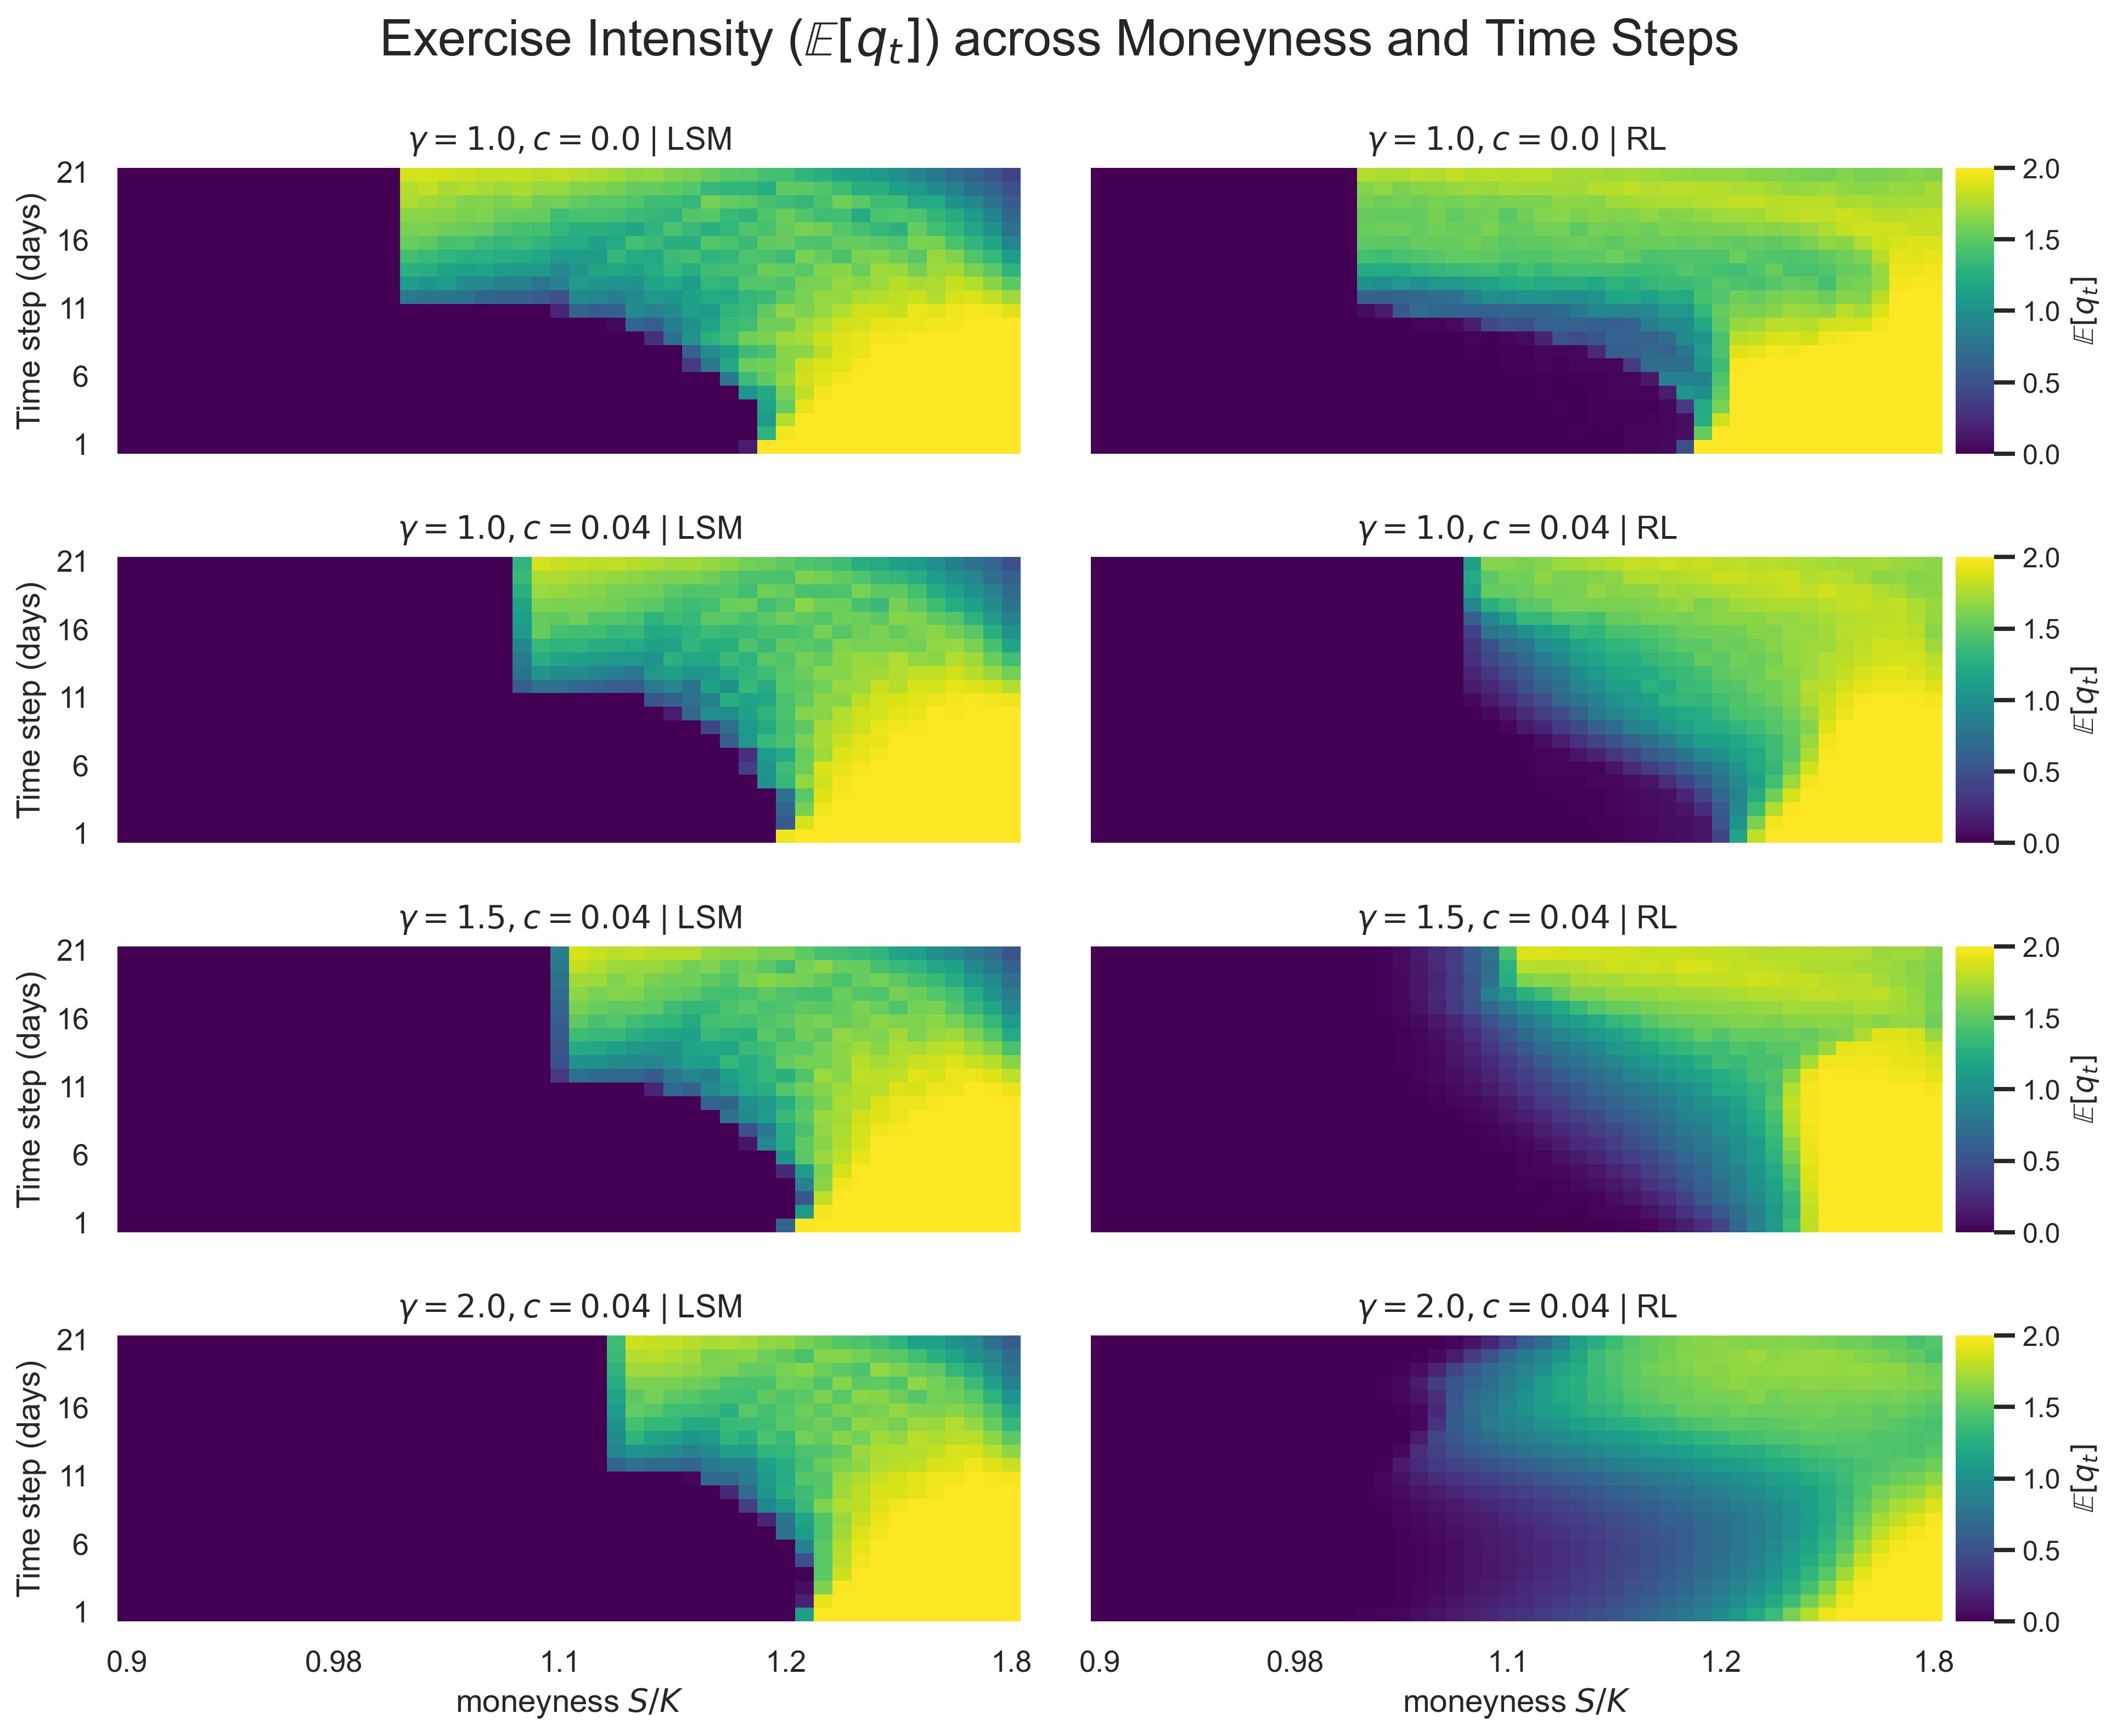

In [8]:
def heatmap_state(df, ax, bins, vmax=2.0, show_xlabel=True, show_ylabel=True, cbar=True, cbar_ax=None):
    d = df.query("time_step > 0").copy()
    d["mny"] = d["spot"] / 1.0
    d["mny_bin"] = pd.cut(d["mny"], bins=bins, include_lowest=True)
    pivot = d.pivot_table(index="time_step", columns="mny_bin", values="q_t", aggfunc="mean", observed=True)
    pivot = pivot.sort_index().reindex(columns=bins)
    
    days = pivot.index.values
    sns.heatmap(
        pivot,
        cmap="viridis",
        vmin=0,
        vmax=vmax,
        cbar=cbar,
        cbar_ax=cbar_ax,
        cbar_kws={"label": r"$\mathbb{E}[q_t]$"} if cbar else None,
        ax=ax,
    )
    
    mids = [(iv.left + iv.right) / 2 for iv in pivot.columns]
    xtick_indices = np.linspace(0, len(mids) - 1, 5, dtype=int)
    ax.set_xticks(xtick_indices + 0.5)
    ax.set_xticklabels([f"{mids[i]:.2g}" for i in xtick_indices], rotation=0)
    
    ytick_indices = np.linspace(0, len(days) - 1, 5, dtype=int)
    ax.set_yticks(ytick_indices + 0.5)
    ax.set_yticklabels([str(int(days[i])) for i in ytick_indices], rotation=0)
    
    xlabel = r"moneyness $S/K$" if show_xlabel else ""
    ylabel = "Time step (days)" if show_ylabel else ""
    ax.set(xlabel=xlabel, ylabel=ylabel)
    ax.invert_yaxis()

HEATMAP_FONTSIZE = 14
HEATMAP_TITLE_SIZE = 22
fig, axes = plt.subplots(
    len(order),
    2,
    figsize=(13.2, 2.8 * len(order)),
    sharex=True,
    sharey=True,
    constrained_layout=False,
    dpi=300,
)
axes = axes.reshape(len(order), 2)
fig.suptitle(
    "Exercise Intensity ($\mathbb{E}[q_t]$) across Moneyness and Time Steps",
    fontsize=HEATMAP_TITLE_SIZE,
    y=0.948,
)

from mpl_toolkits.axes_grid1 import make_axes_locatable

for row, lbl in enumerate(order):
    rd = next(d for d in data if d["spec"]["label"] == lbl)
    mny_all = pd.concat([rd["lsm_df"]["spot"], rd["rl_df"]["spot"]])
    mny_all = mny_all[(mny_all >= 0.9) & (mny_all <= 2.0)]
    cats = pd.qcut(mny_all, q=50, duplicates="drop")
    edges = np.unique(np.r_[cats.cat.categories[0].left, [c.right for c in cats.cat.categories]])
    bins = pd.IntervalIndex.from_breaks(edges)
    
    spec = rd["spec"]
    title_prefix = f"$\\gamma={spec['gamma']}, c={spec['c']}$"
    
    heatmap_state(
        rd["lsm_df"],
        axes[row, 0],
        bins=bins,
        show_xlabel=(row == len(order) - 1),
        show_ylabel=True,
        cbar=False,
    )
    axes[row, 0].set_title(f"{title_prefix} | LSM", fontsize=HEATMAP_FONTSIZE, pad=8)
    axes[row, 0].tick_params(axis="both", labelsize=HEATMAP_FONTSIZE - 1)
    axes[row, 0].xaxis.label.set_size(HEATMAP_FONTSIZE)
    axes[row, 0].yaxis.label.set_size(HEATMAP_FONTSIZE)
    
    divider = make_axes_locatable(axes[row, 1])
    cax = divider.append_axes("right", size="4.5%", pad=0.08)
    heatmap_state(
        rd["rl_df"],
        axes[row, 1],
        bins=bins,
        show_xlabel=(row == len(order) - 1),
        show_ylabel=False,
        cbar=True,
        cbar_ax=cax,
    )
    axes[row, 1].set_title(f"{title_prefix} | RL", fontsize=HEATMAP_FONTSIZE, pad=8)
    axes[row, 1].tick_params(axis="both", labelsize=HEATMAP_FONTSIZE - 1)
    axes[row, 1].xaxis.label.set_size(HEATMAP_FONTSIZE)
    cax.tick_params(labelsize=HEATMAP_FONTSIZE - 2)
    cax.yaxis.label.set_size(HEATMAP_FONTSIZE - 1)

fig.tight_layout(rect=[0, 0, 1, 0.965])
save_fig(fig, "hist_exercise")
plt.show()

## Expanded synopsis across configs

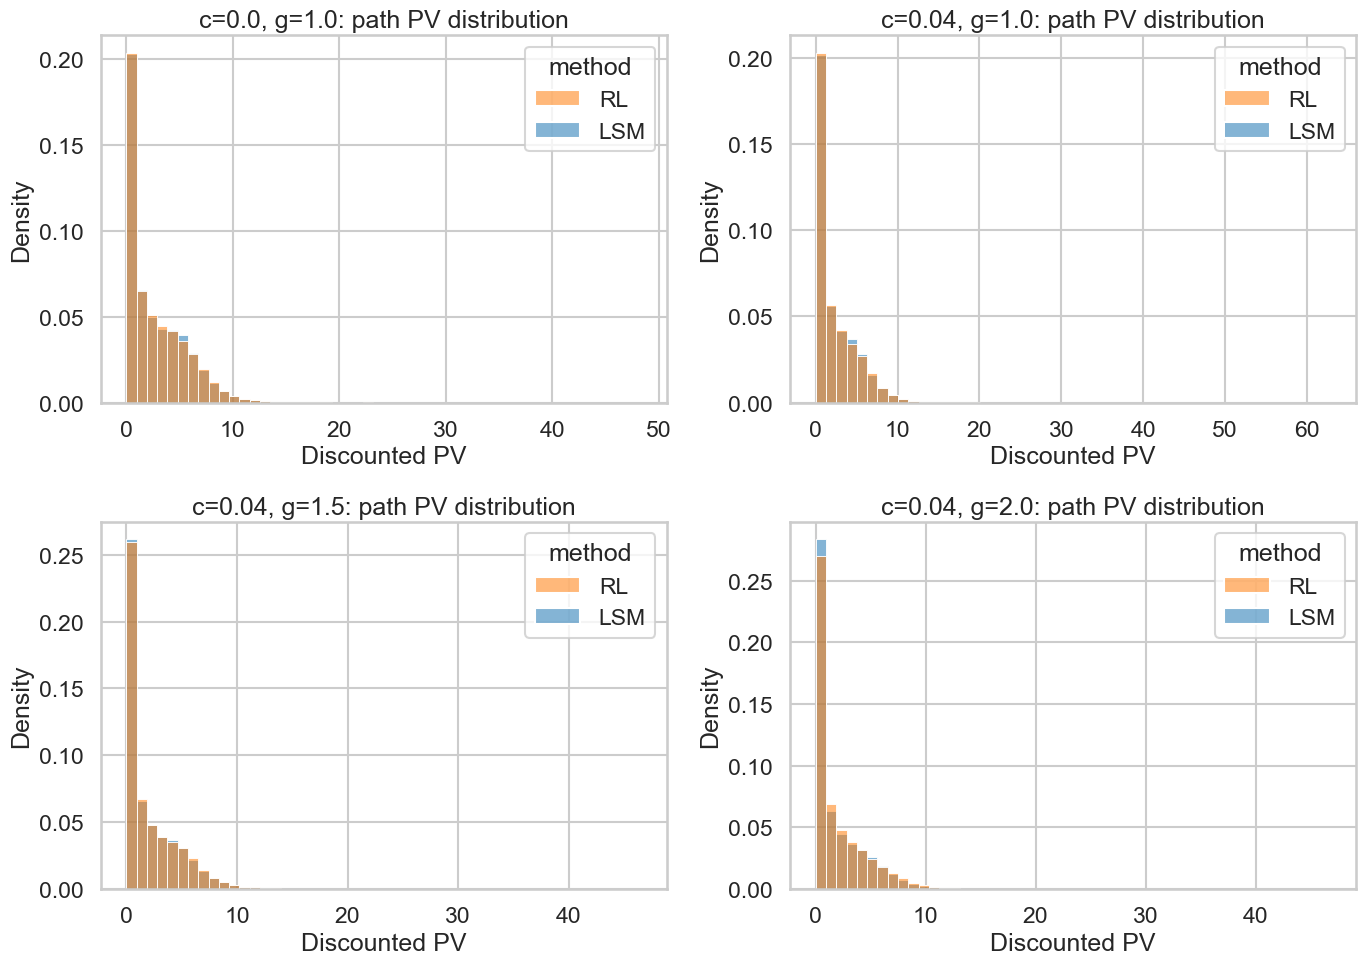

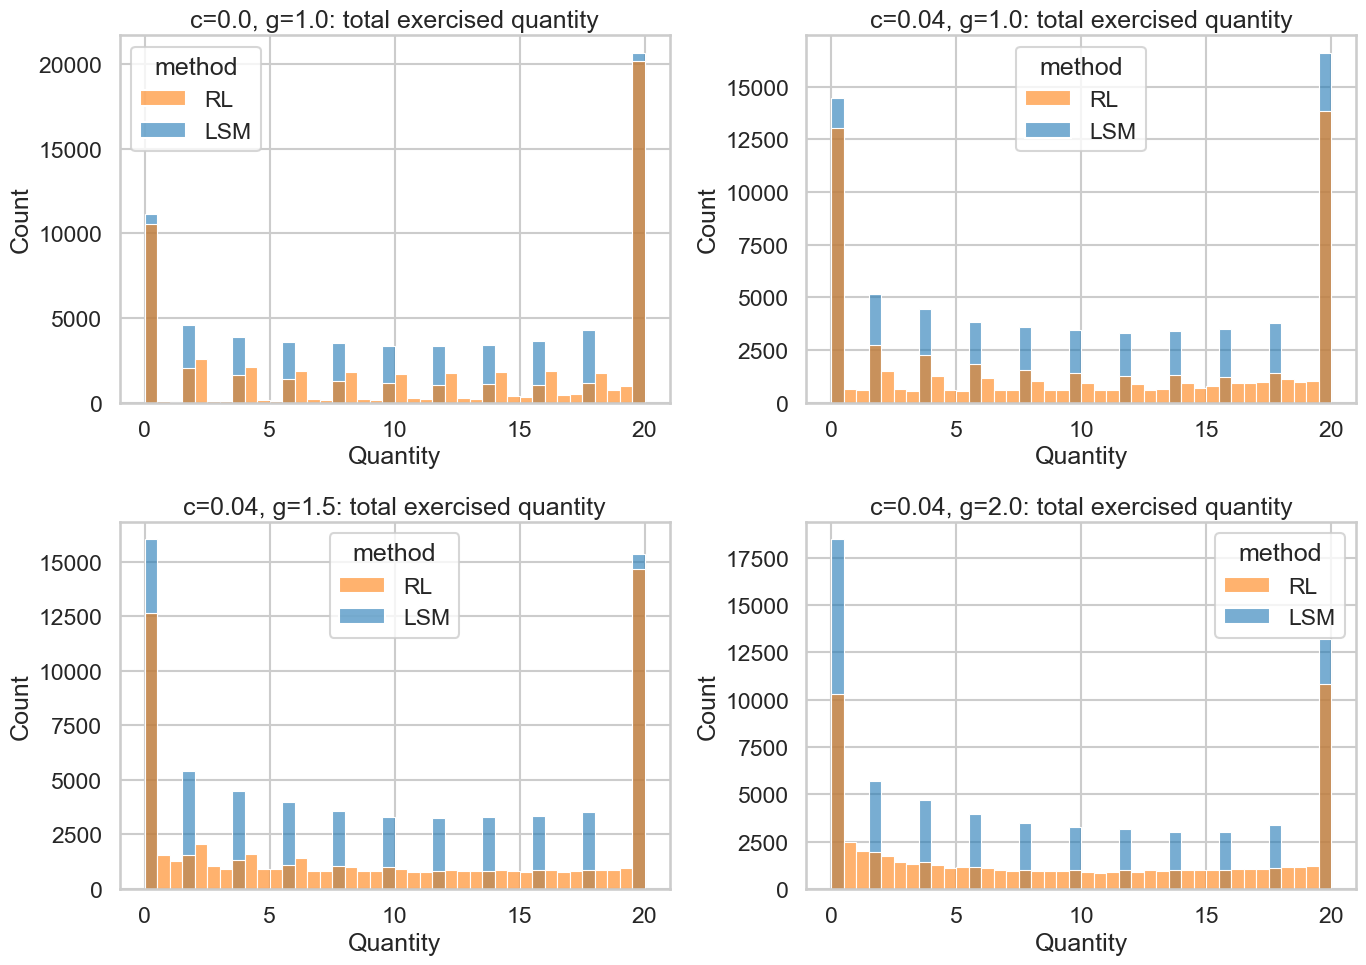

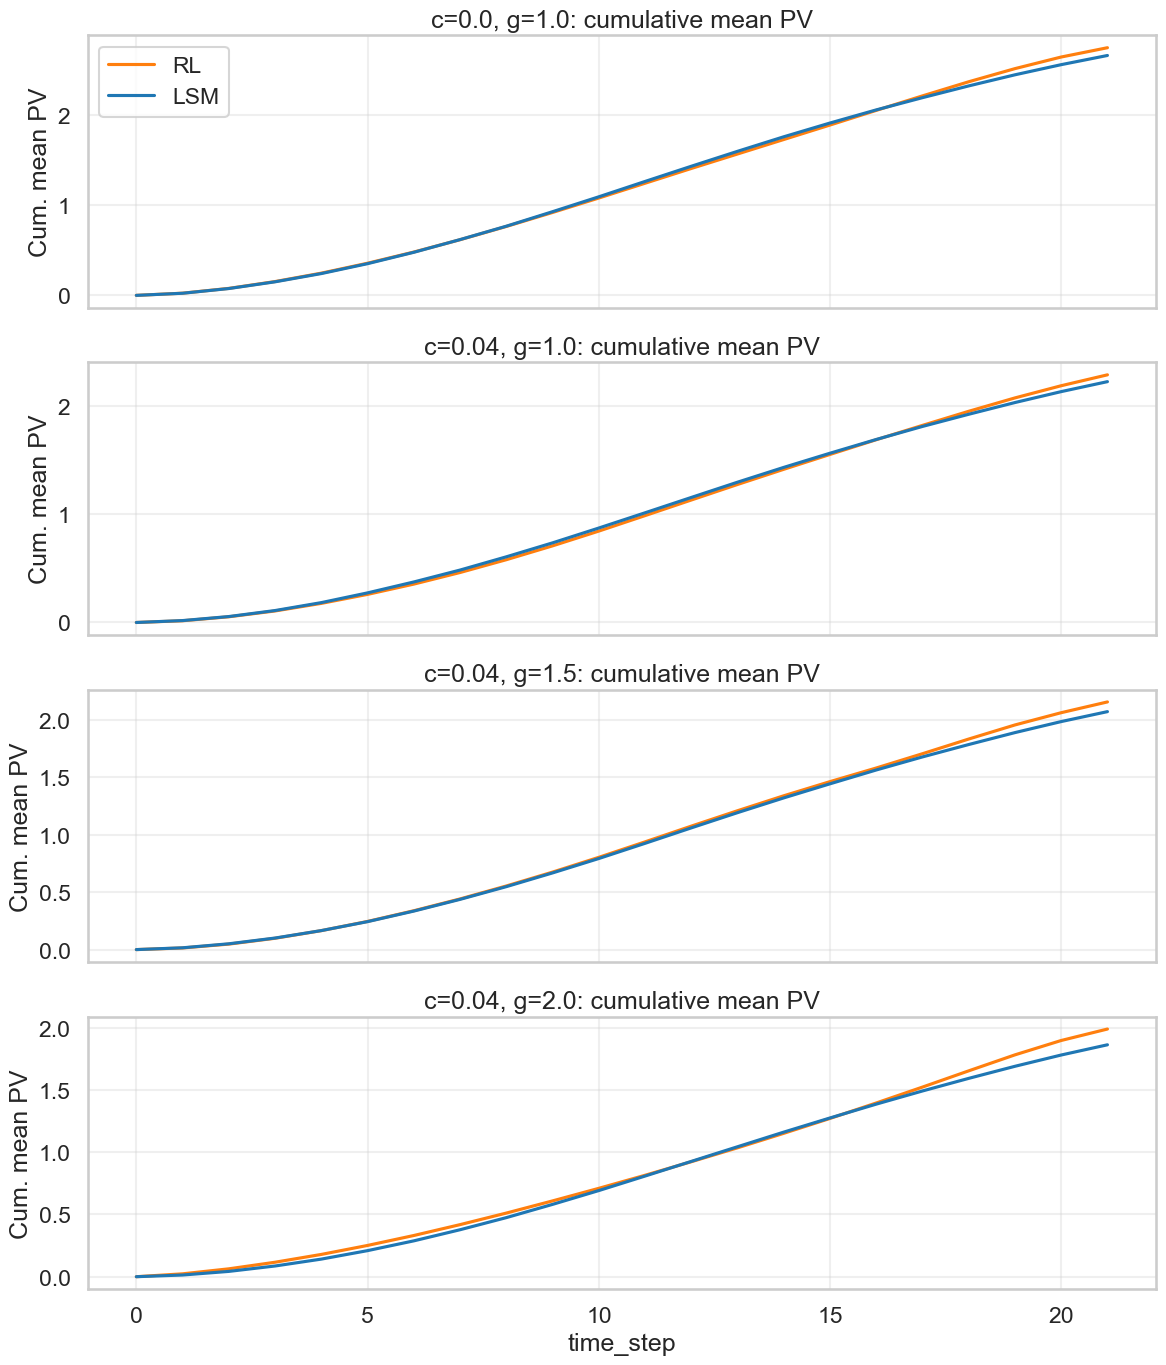

In [34]:
palette = {"RL": "tab:orange", "LSM": "tab:blue"}

# PV distribution histograms
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for ax, lbl in zip(axes.ravel(), order):
    sub = paths_all.query("label == @lbl")
    sns.histplot(sub, x="net_pv", hue="method", bins=50, palette=palette, ax=ax, stat="density", alpha=0.55)
    ax.set(title=f"{label_map[lbl]}: path PV distribution", xlabel="Discounted PV", ylabel="Density")
plt.tight_layout(); plt.show()

# Quantity distribution histograms
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for ax, lbl in zip(axes.ravel(), order):
    sub = paths_all.query("label == @lbl")
    sns.histplot(sub, x="qty", hue="method", bins=40, palette=palette, ax=ax, alpha=0.6)
    ax.set(title=f"{label_map[lbl]}: total exercised quantity", xlabel="Quantity", ylabel="Count")
plt.tight_layout(); plt.show()

# Cumulative mean PV over time
ts_curves = []
for spec in RUN_SPECS:
    with open(spec["config_path"]) as f: cfg = json.load(f)
    dt = cfg["maturity"] / cfg["n_rights"]
    for method, p in [("RL", spec["rl_path"]), ("LSM", spec["lsm_path"])]:
        df = pd.read_parquet(p)
        if method == "RL":
            net = df["reward"]
        else:
            net = df["payoff"] * np.exp(-cfg["risk_free_rate"] * (df["time_step"] + 1) * dt)
        curve = pd.DataFrame({"time_step": df["time_step"], "net": net}).groupby("time_step")["net"].mean().sort_index().cumsum().reset_index(name="cum_pv")
        curve["label"], curve["method"] = spec["label"], method
        ts_curves.append(curve)
ts_payoff = pd.concat(ts_curves)

fig, axes = plt.subplots(len(order), 1, figsize=(12, 3.5 * len(order)), sharex=True)
if len(order) == 1: axes = [axes]
for ax, lbl in zip(axes, order):
    sub = ts_payoff.query("label == @lbl")
    for m, c in palette.items():
        ax.plot(sub.query("method == @m")["time_step"], sub.query("method == @m")["cum_pv"], label=m, color=c)
    ax.set(title=f"{label_map[lbl]}: cumulative mean PV", ylabel="Cum. mean PV"); ax.grid(alpha=0.3)
axes[-1].set_xlabel("time_step"); axes[0].legend()
plt.tight_layout(); plt.show()


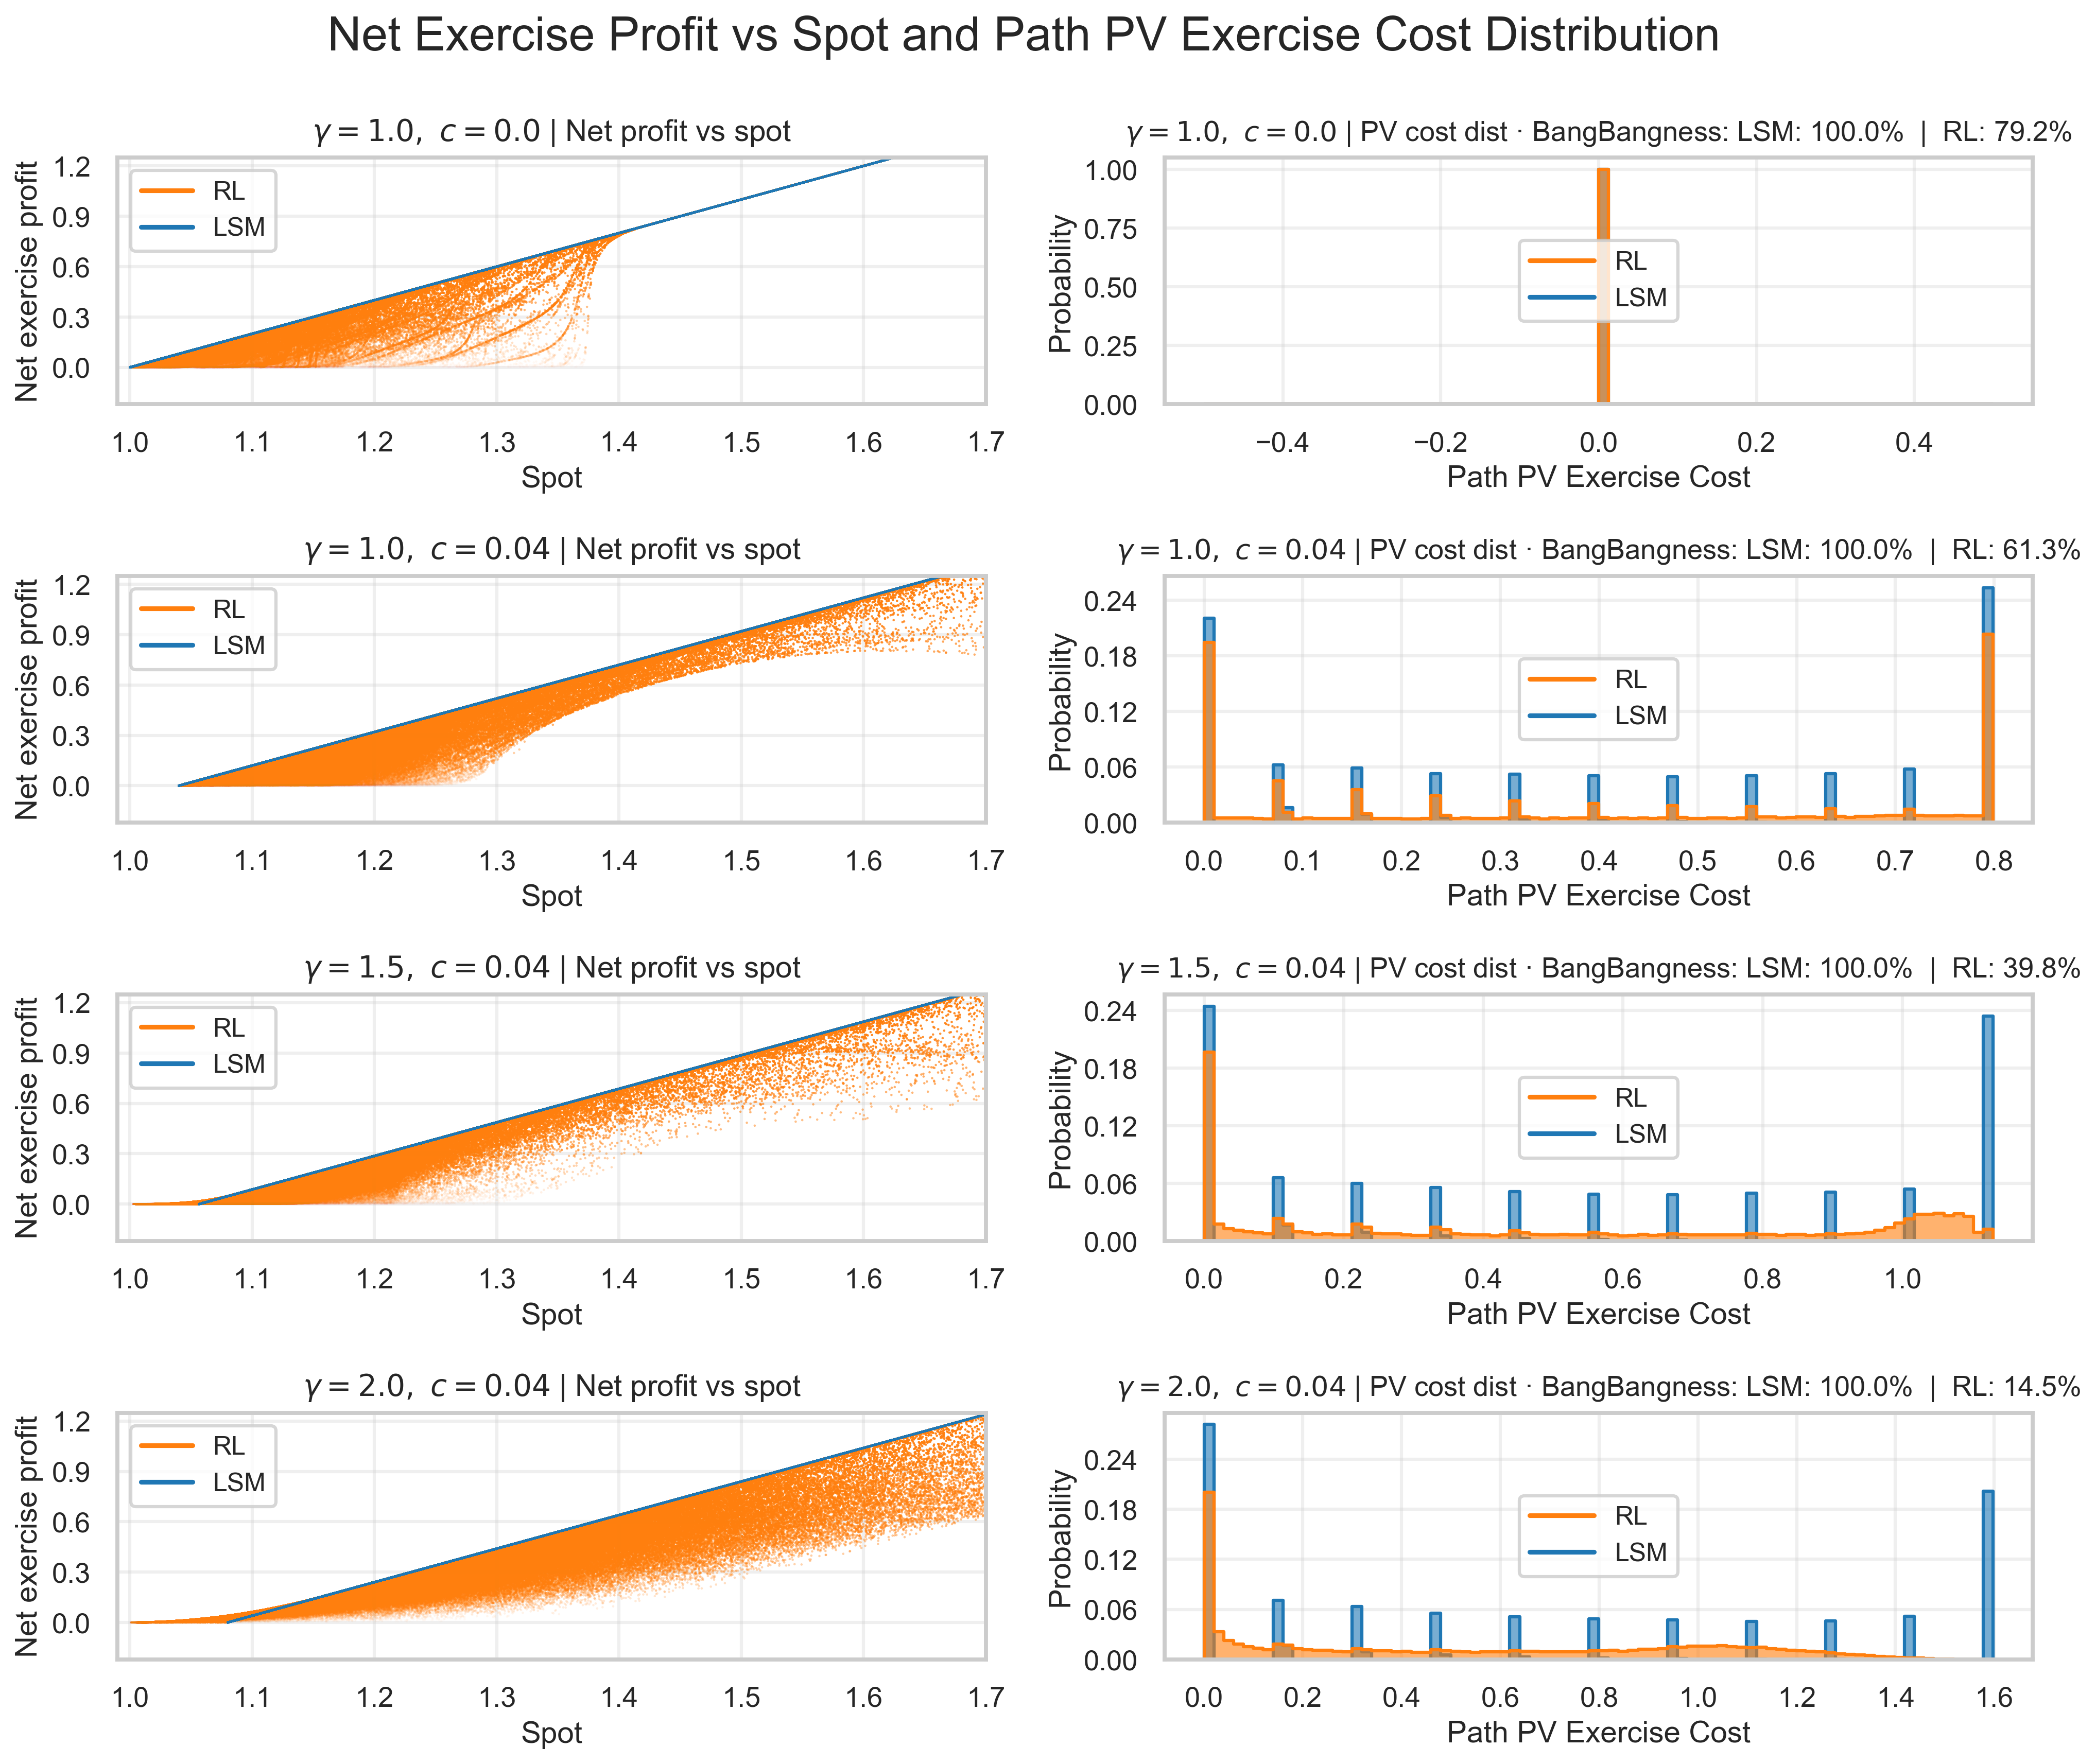

In [9]:
import matplotlib.colors as mcolors
from matplotlib.lines import Line2D

FONTSIZE = 14
TITLE_SIZE = 22
palette = {"RL": "tab:orange", "LSM": "tab:blue"}
rgba_colors = {'RL': mcolors.to_rgba('tab:orange'), 'LSM': mcolors.to_rgba('tab:blue')}
legend_handles = [
    Line2D([0], [0], color='tab:orange', linewidth=2.2, label='RL'),
    Line2D([0], [0], color='tab:blue', linewidth=2.2, label='LSM'),
]

n_rows = len(order)
fig, axes = plt.subplots(n_rows, 2, figsize=(13.6, 3.0 * n_rows), dpi=300)
axes = axes.reshape(n_rows, 2)

fig.suptitle(
    "Net Exercise Profit vs Spot and Path PV Exercise Cost Distribution",
    fontsize=TITLE_SIZE, y=0.958
)

for i, d in enumerate(data):
    spec = d['spec']
    cfg = d['cfg']
    lbl = spec['label']
    title_prefix = f"$\\gamma={spec['gamma']},\\ c={spec['c']}$"

    dt = cfg['maturity'] / cfg['n_rights']
    Q_max = cfg.get('Q_max', 20.0)
    q_max = cfg.get('q_max', 2.0)

    scatter_parts = []
    for method, df_raw in [("RL", d['rl_df']), ("LSM", d['lsm_df'])]:
        ex_mask = df_raw['q_t'].values > 1e-5
        if method == "RL":
            q_before = df_raw['q_remaining_norm'].values * Q_max
        else:
            q_before = Q_max - df_raw['q_exercised_so_far'].values
        cond_mask = ex_mask & (q_before >= q_max)
        df_cond = df_raw.iloc[cond_mask]
        discount = np.exp(-cfg['risk_free_rate'] * (df_cond['time_step'].values + 1) * dt)
        net_exercise_profit = df_cond['reward'].values / discount if method == "RL" else df_cond['payoff'].values
        scatter_parts.append(pd.DataFrame({
            'spot': df_cond['spot'].values,
            'net_exercise_profit': net_exercise_profit,
            'q_t': df_cond['q_t'].values,
            'method': method
        }))
    df_scatter = pd.concat(scatter_parts, ignore_index=True)

    def compute_bangbangness(df_raw, method, Q_max, q_max):
        if df_raw is None or len(df_raw) == 0:
            return 0.0
        if method == "RL":
            q_rem = df_raw['q_remaining_norm'] * Q_max
        else:
            q_rem = Q_max - df_raw['q_exercised_so_far']
        capable = df_raw[q_rem >= (q_max - 1e-5)]
        ex = capable[capable['q_t'] > 1e-5]
        if len(ex) == 0:
            return 0.0
        return (ex['q_t'] >= 0.95 * q_max).mean()

    rl_bb = compute_bangbangness(d['rl_df'], "RL", Q_max, q_max)
    lsm_bb = compute_bangbangness(d['lsm_df'], "LSM", Q_max, q_max)

    ax_left = axes[i, 0]
    for method, m_size in [("RL", 1.2), ("LSM", 1.1)]:
        df_m = df_scatter[df_scatter['method'] == method]
        if len(df_m) == 0:
            continue
        c_base = rgba_colors[method]
        alphas = np.clip(df_m['q_t'].values / q_max, 0, 1)
        colors = np.tile(c_base, (len(df_m), 1))
        colors[:, 3] = alphas
        ax_left.scatter(
            df_m['spot'],
            df_m['net_exercise_profit'],
            c=colors,
            s=m_size,
            edgecolors='none',
            rasterized=True,
        )

    ax_left.set_title(f"{title_prefix} | Net profit vs spot", fontsize=FONTSIZE, pad=8)
    ax_left.set_xlabel("Spot", fontsize=FONTSIZE)
    ax_left.set_ylabel("Net exercise profit", fontsize=FONTSIZE)
    ax_left.tick_params(axis='both', labelsize=FONTSIZE - 1)
    ax_left.set_xlim(0.99, 1.70)
    ax_left.set_ylim(-0.22, 1.25)
    ax_left.yaxis.set_major_locator(plt.MaxNLocator(5))
    ax_left.grid(alpha=0.3)
    ax_left.legend(legend_handles, ['RL', 'LSM'], loc='upper left', fontsize=FONTSIZE - 2)

    ax_right = axes[i, 1]
    sns.histplot(
        data=path_stats.query("label == @lbl"),
        x="PV_cost",
        hue="method",
        bins=80,
        palette=palette,
        element="step",
        stat="probability",
        common_norm=False,
        ax=ax_right,
        alpha=0.6,
        legend=False,
    )

    polarity_label = f"LSM: {lsm_bb:.1%}  |  RL: {rl_bb:.1%}"
    ax_right.set_title(
        f"{title_prefix} | PV cost dist · BangBangness: {polarity_label}",
        fontsize=FONTSIZE - 1,
        pad=8,
    )
    ax_right.set_xlabel("Path PV Exercise Cost", fontsize=FONTSIZE)
    ax_right.set_ylabel("Probability", fontsize=FONTSIZE)
    ax_right.tick_params(axis='both', labelsize=FONTSIZE - 1)
    ax_right.yaxis.set_major_locator(plt.MaxNLocator(5))
    ax_right.grid(alpha=0.3)
    ax_right.legend(
        handles=legend_handles,
        labels=['RL', 'LSM'],
        loc='center',
        title=None,
        fontsize=FONTSIZE - 2,
        frameon=True,
        handlelength=2.5,
    )

fig.tight_layout(rect=[0, 0, 1, 0.972])
fig.savefig(FIG_DIR / "spot_income_pv_hist.png", bbox_inches="tight", dpi=300)
plt.show()

## Bang-Bangness: quantifying optimal discrete exercise

### Motivation

For swing options with **linear** costs ($\gamma = 1$), the optimal exercise policy is provably **bang-bang**: whenever the holder exercises, they should exercise the maximum possible quantity. Under **convex** costs ($\gamma > 1$), the optimal policy often involves partial exercises to avoid the high marginal costs of large single-step actions.

We define **Bang-Bangness ($B$)** as a robust statistical metric to measure how often an agent adheres to this all-or-nothing behavior when it is feasible to do so.

### Statistical Definition

We consider the subset of time steps $t$ where:
1. **Feasibility**: Full capacity was available ($Q_t \geq q_{\max}$).
2. **Action**: The agent chose to exercise a non-zero amount ($q_t > \epsilon$).

For these instances, we calculate the **Hit-Ratio**: the percentage of exercises that reached at least 95% of the maximum allowed quantity $q_{\max}$.

$$
B = P\left( \frac{q_t}{q_{\max}} \geq 0.95 \;\middle|\; Q_t \geq q_{\max}, \; q_t > 0 \right)
$$

- **100%**: Purely bang-bang. Every exercise hits the limit.
- **0%**: No exercise ever hits the limit (e.g., purely distributed/partial fills).
- **~5%**: Expected value for a purely **Uniform** random agent on $(0, q_{\max}]$.

This metric is simple, robust, and directly interpretable as the fidelity of the agent to a bang-bang control strategy.


In [17]:
# --- Compute BangBangness for ALL configurations and write to CSV ---
CSV_PATH = REPO_ROOT / "Jupyter Notebooks/Convex Costs Results 6.csv"

def compute_bangbangness(df_raw, method, Q_max, q_max):
    if df_raw is None or len(df_raw) == 0:
        return np.nan
    
    if method == "RL":
        q_rem = df_raw['q_remaining_norm'] * Q_max
    else:
        q_rem = Q_max - df_raw['q_exercised_so_far']
    
    capable_df = df_raw[q_rem >= (q_max - 1e-5)]
    ex = capable_df[capable_df['q_t'] > 1e-5]
    if len(ex) == 0:
        return np.nan
    
    return (ex['q_t'] >= 0.95 * q_max).mean()

results_df = pd.read_csv(CSV_PATH)
rl_bb, lsm_bb = [], []

for _, row in results_df.iterrows():
    cfg, seed, step = row['Configuration'], int(row['Best Seed']), int(row['Best Episode'])
    run_name = f"{cfg}_{seed}"
    eval_dir = LOGS_DIR / run_name / "evaluations"
    rl_path, lsm_path = eval_dir / f"rl_episode_{step}.parquet", eval_dir / "lsm.parquet"
    
    try:
        with open(RUNS_DIR / f"{run_name}.json") as f:
            cfg_data = json.load(f)
        Q_max, q_max = cfg_data.get('Q_max', 20.0), cfg_data.get('q_max', 2.0)
    except Exception:
        Q_max, q_max = 20.0, 2.0
    
    try:
        rl_bb.append(compute_bangbangness(pd.read_parquet(rl_path), "RL", Q_max, q_max))
    except Exception:
        rl_bb.append(np.nan)
    
    try:
        lsm_bb.append(compute_bangbangness(pd.read_parquet(lsm_path), "LSM", Q_max, q_max))
    except Exception:
        lsm_bb.append(np.nan)

results_df['RL_BangBangness'], results_df['LSM_BangBangness'] = rl_bb, lsm_bb
results_df.to_csv(CSV_PATH, index=False)
results_df[['Configuration', 'c', 'gamma', 'RL_BangBangness', 'LSM_BangBangness']].sort_values(by=['c', 'gamma'])

,Configuration,c,gamma,RL_BangBangness,LSM_BangBangness
0,SwingOption_20_c0.00_gamma1,0.000000,1.000000,0.792267,1.000000
1,SwingOption_20_c0.01_gamma1,0.010000,1.000000,0.727870,1.000000
2,SwingOption_20_c0.01_gamma1.5,0.010000,1.500000,0.621062,1.000000
3,SwingOption_20_c0.01_gamma2,0.010000,2.000000,0.368418,1.000000
4,SwingOption_20_c0.01_gamma3,0.010000,3.000000,0.235058,1.000000
5,SwingOption_20_c0.02_gamma1,0.020000,1.000000,0.638403,1.000000
6,SwingOption_20_c0.02_gamma1.5,0.020000,1.500000,0.475997,1.000000
7,SwingOption_20_c0.02_gamma2,0.020000,2.000000,0.371946,1.000000
8,SwingOption_20_c0.02_gamma3,0.020000,3.000000,0.106417,1.000000
9,SwingOption_20_c0.04_gamma1,0.040000,1.000000,0.612799,1.000000


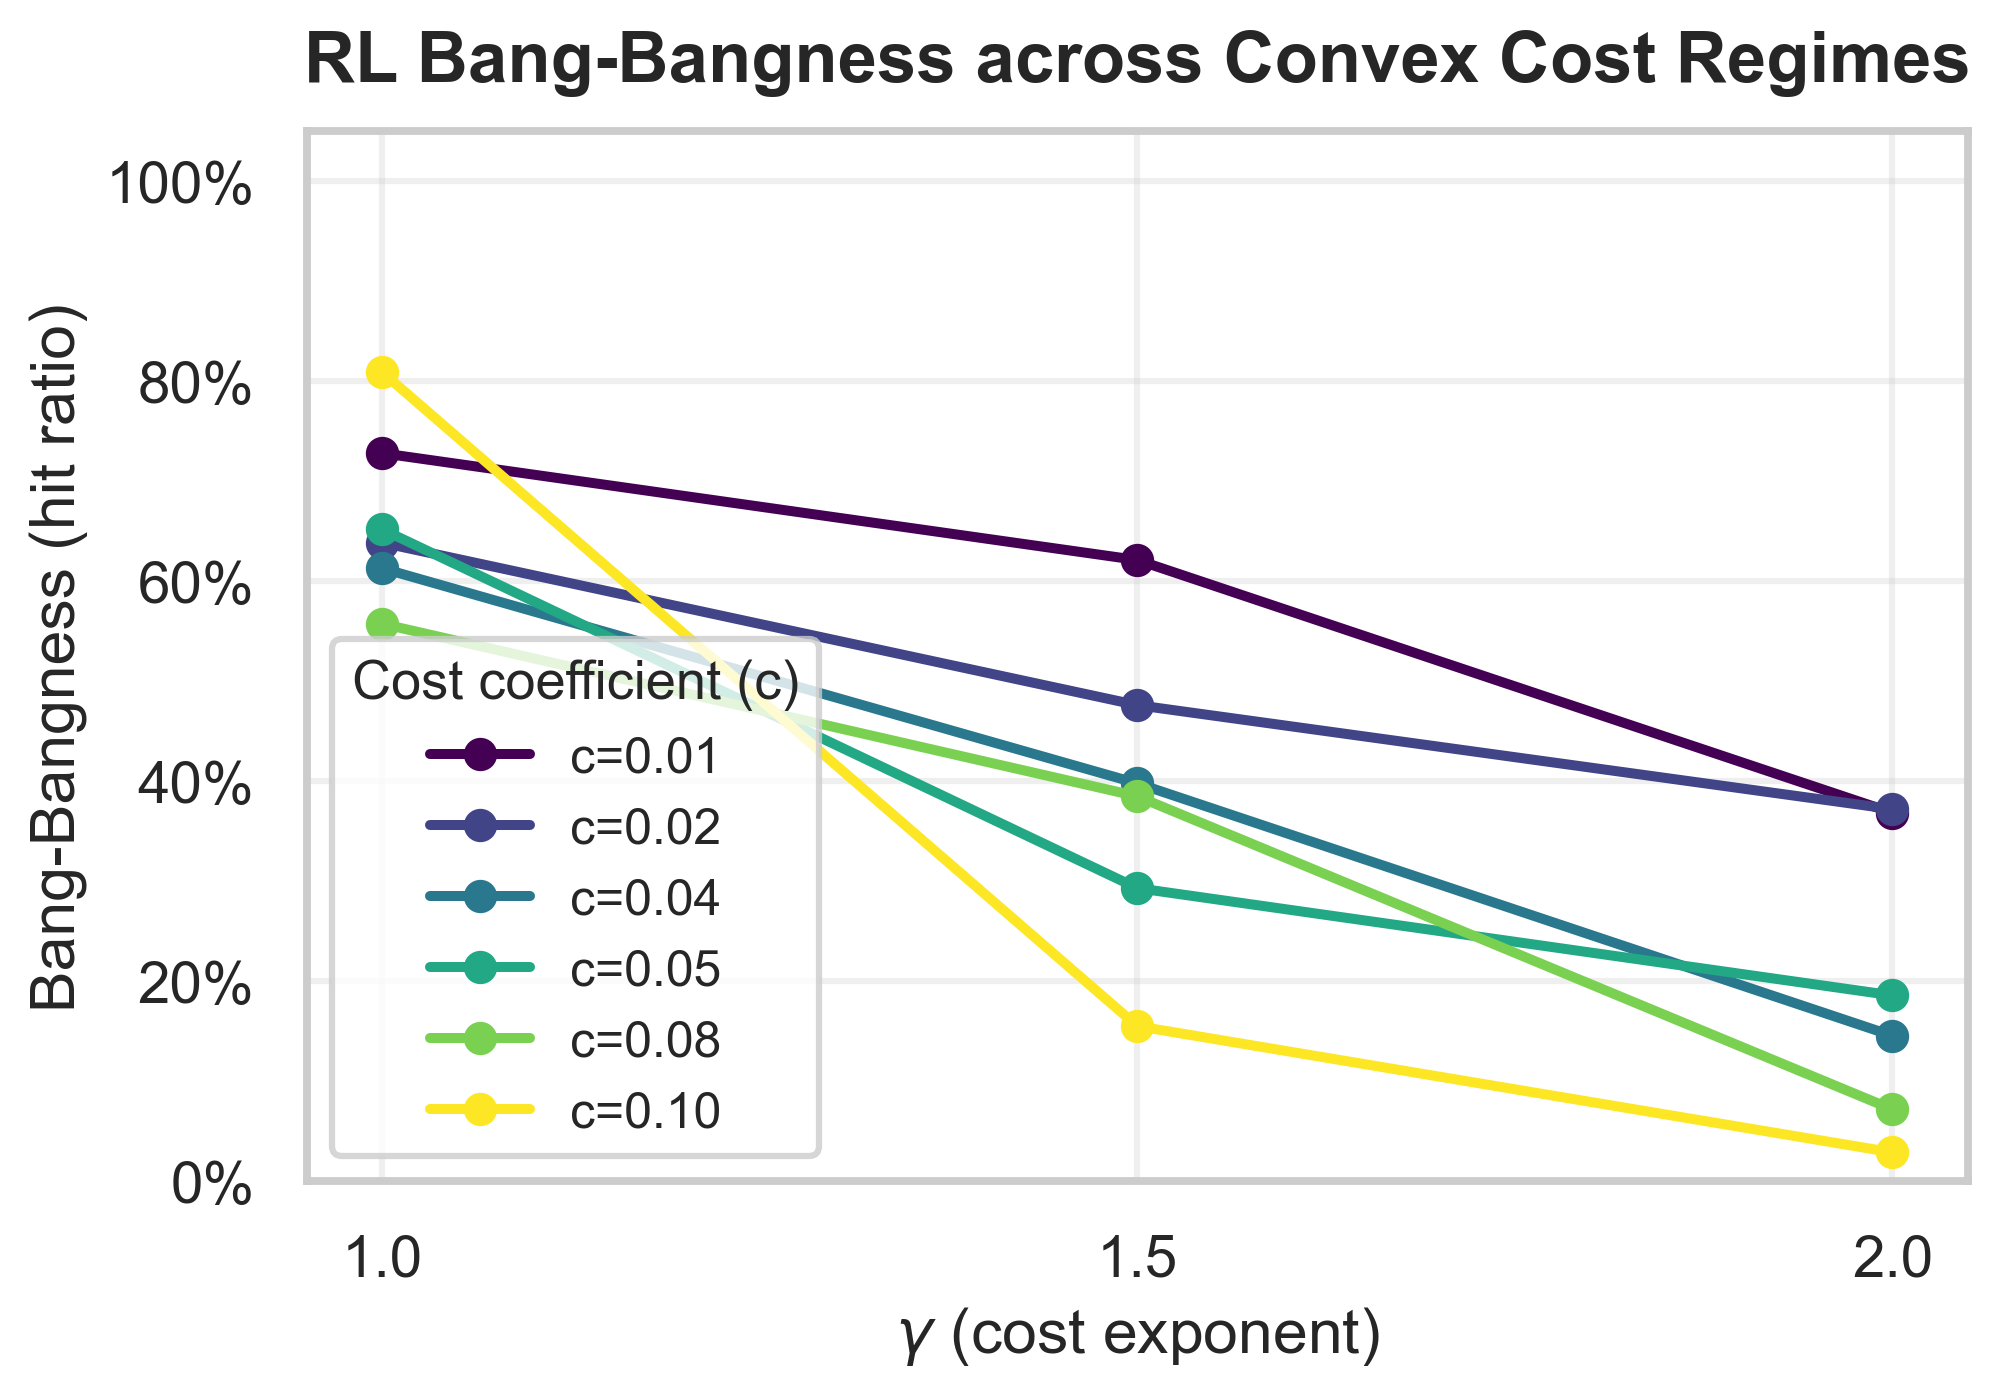

In [21]:
# --- BangBangness visualisation (RL Only) ---
REDUCED_SET = True  # Toggle: only include cost configurations with all 3 core regimes (gamma=1, 1.5, 2)
CSV_PATH = REPO_ROOT / "Jupyter Notebooks/Convex Costs Results 6.csv"

FONTSIZE = 15
sns.set_theme(style="whitegrid", context="talk")

df = pd.read_csv(CSV_PATH)
df = df.dropna(subset=['RL_BangBangness'])

# Force restriction to gamma regimes 1, 1.5, 2 (ignoring gamma=3)
plot_df = df[df['gamma'] <= 2.2]

if REDUCED_SET:
    # Filter for costs that have all three core gamma regimes (1, 1.5, 2)
    plot_df = plot_df[plot_df.groupby('c')['gamma'].transform('count') == 3]

c_values = sorted(plot_df['c'].unique())
gamma_values = [1.0, 1.5, 2.0]

fig, ax = plt.subplots(1, 1, figsize=(7.0, 5.0), dpi=300)

cmap = plt.cm.viridis
n_c = len(c_values)
c_colors = {c_val: cmap(i / max(n_c - 1, 1)) for i, c_val in enumerate(c_values)}

for c_val in c_values:
    sub = plot_df[plot_df['c'] == c_val].sort_values('gamma')
    color = c_colors[c_val]
    ax.plot(
        sub['gamma'],
        sub['RL_BangBangness'],
        'o-',
        color=color,
        label=f"c={c_val:.2f}",
        markersize=7,
        linewidth=2.4,
    )

ax.set_title("RL Bang-Bangness across Convex Cost Regimes", fontsize=FONTSIZE + 2, fontweight='bold', pad=12)
ax.set_xlabel(r'$\gamma$ (cost exponent)', fontsize=FONTSIZE)
ax.set_ylabel('Bang-Bangness (hit ratio)', fontsize=FONTSIZE)
ax.tick_params(axis='both', labelsize=FONTSIZE - 1)
ax.set_ylim(0, 1.05)
ax.set_xticks(gamma_values)
ax.set_yticklabels([f"{x:.0%}" for x in ax.get_yticks()])
ax.legend(
    fontsize=FONTSIZE - 3,
    loc='lower left',
    title="Cost coefficient (c)",
    title_fontsize=FONTSIZE - 2,
    frameon=True,
)
ax.grid(alpha=0.3)

fig.tight_layout()
fig.savefig(FIG_DIR / "bang_bangness_rl.pdf", bbox_inches="tight", dpi=300)
plt.show()


## Sensitivity Analysis of the Bang-Bangness Threshold

How does the Bang-Bangness metric $B$ change as we vary the threshold $k$? We evaluate the RL agent for $c=0.05$ across the core $\gamma$ regimes to observe how the exercise distribution shifts. Ideally, the metric should be stable around the chosen threshold while clearly distinguishing between bang-bang and distributed policies.


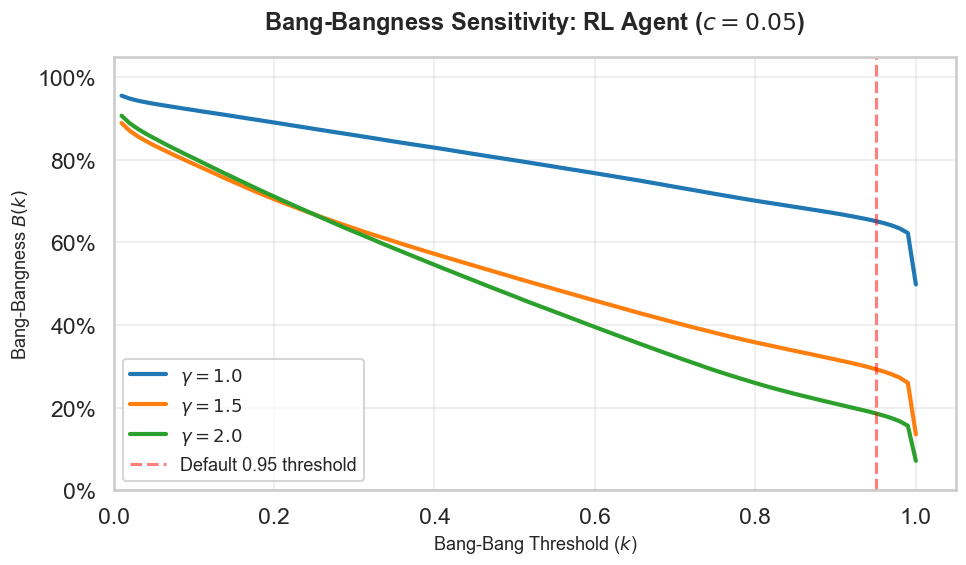

In [72]:
# --- Sensitivity Analysis: Impact of Threshold (k) --- 
threshold_grid = np.linspace(0.01, 1.0, 100)
gamma_targets = [1.0, 1.5, 2.0]
c_target = 0.05

results_map = {}

for g in gamma_targets:
    match = results_df[(results_df['c'] == c_target) & (results_df['gamma'] == g)]
    if match.empty: continue
    row = match.iloc[0]
    cfg, seed, step = row['Configuration'], int(row['Best Seed']), int(row['Best Episode'])
    run_name = f"{cfg}_{seed}"
    
    # Load evaluation parquet
    rl_path = LOGS_DIR / run_name / "evaluations" / f"rl_episode_{step}.parquet"
    df_ev = pd.read_parquet(rl_path)
    
    with open(RUNS_DIR / f"{run_name}.json") as f: cfg_data = json.load(f)
    Q_max, q_max = cfg_data.get('Q_max', 20.0), cfg_data.get('q_max', 2.0)

    # 1. Feasibility: Q_rem >= q_max
    q_rem = df_ev['q_remaining_norm'] * Q_max
    capable = df_ev[q_rem >= (q_max - 1e-5)]
    
    # 2. Decision: Only exercise events > 0
    ratios = capable[capable['q_t'] > 1e-5]['q_t'].values / q_max
    
    # 3. Hit-ratio curve
    curve = [(ratios >= k).mean() for k in threshold_grid]
    results_map[g] = curve

fig, ax = plt.subplots(figsize=(10, 6))
colors = {1.0: "tab:blue", 1.5: "tab:orange", 2.0: "tab:green"}

for g, curve in results_map.items():
    ax.plot(threshold_grid, curve, label=f"$\\gamma={g}$", color=colors[g], linewidth=3)

ax.axvline(0.95, color='red', linestyle='--', alpha=0.5, label="Default 0.95 threshold")
ax.set_xlabel("Bang-Bang Threshold ($k$)", fontsize=FONTSIZE)
ax.set_ylabel("Bang-Bangness $B(k)$", fontsize=FONTSIZE)
ax.set_title(f"Bang-Bangness Sensitivity: RL Agent ($c={c_target}$)", 
             fontsize=FONTSIZE+4, fontweight='bold', pad=20)

ax.set_xlim(0, 1.05)
ax.set_ylim(0, 1.05)
ax.set_yticklabels([f"{x:.0%}" for x in ax.get_yticks()])
ax.legend(fontsize=FONTSIZE)
ax.grid(True, alpha=0.3)
plt.tight_layout()
fig.savefig(FIG_DIR / "bang_bangness_sensitivity.png", bbox_inches="tight", dpi=300)
plt.show()
